**Pontificia Universidad Javeriana**  
**Procesamiento de Alto Volumen de Datos**  
**Fecha:** 28 de abril de 2026  
**Autor:** Sebastian Angulo Vergara  

## Objetivos del Laboratorio

### Objetivo General
Desarrollar un pipeline completo de clasificación supervisada sobre un dataset de marketing bancario utilizando PySpark ML, desde la ingesta y exploración de datos hasta la evaluación comparativa de múltiples modelos predictivos.

### Objetivos Específicos
- Configurar e inicializar una sesión distribuida de Apache Spark para el procesamiento de grandes volúmenes de datos
- Cargar e inspeccionar el dataset de banca (`bank-full.csv`), comprendiendo la estructura, tipos de datos y significado de cada variable
- Realizar un análisis exploratorio de datos (EDA) mediante estadísticas descriptivas y visualizaciones que permitan identificar patrones, distribuciones y relaciones entre variables
- Detectar y tratar problemas de calidad de datos: valores nulos, outliers, variables centinela y desbalance de clases
- Preparar y transformar las características mediante codificación de variables categóricas (StringIndexer, OneHotEncoder) y ensamble de vectores (VectorAssembler) dentro de un Pipeline de PySpark ML
- Entrenar y comparar seis modelos de clasificación supervisada: Regresión Logística, Random Forest, Árbol de Decisión, Gradient Boosted Trees, SVM y Red Neuronal Multicapa
- Evaluar el desempeño de cada modelo mediante métricas de clasificación (Accuracy, Precision, Recall, F1-Score, AUC-ROC) y matrices de confusión
- Recomendar el modelo más adecuado para predecir la suscripción de depósitos a plazo fijo, considerando tanto el rendimiento como la interpretabilidad

In [1]:
##Importacion de bibliotecas basicas
import os
import sys
import pandas as pd   #---> Para graficar y objetos del dataframe
import numpy as np    #---> Para operaciones matematicas
import matplotlib.pyplot as plt  #---> Para graficar
import seaborn as sns  #---> Para graficar y estadistica

## Bibliotecas especializadas
import findspark
findspark.init('/Almacen/Spark')
from pyspark.sql import functions as F 
from pyspark import SparkContext, SparkConf #---> Para crear el contexto de spark
from pyspark.sql import SQLContext, SparkSession, Row #--->Sesion de Pyspark para consultas SQL
from pyspark.sql.types import *

from pyspark.ml. feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark. ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
#Se requiere levantar la sesion para trabajar con los servicios
#Basados en Spark: Procesamiento paralelo y distribuido sobre grande volumenes de datoa
configura = SparkConf()
#Se debe asignar un puerto manuamente por la capacidad de los puertos
configura.set("spark.scheduler.mode","FAIR")
configura.set("spark.scheduler","/Almacen/Spark/conf/fairscheduler.xml")
configura.setMaster("spark://10.43.97.166:7077")
configura.setAppName("Banca_Angulo_Spark")
# Se asigna la sesion de spark con su respectiva configuracion
sparkAngulo=SparkSession.builder.config(conf=configura).getOrCreate()
sparkAngulo

In [3]:
## Se crea el dataframe para acceder al Sistema
## de fichero csv como un objeto dataframe PySpark
df00 = sparkAngulo.read.format("csv").option("header","true").option("sep",";").load("bank-full.csv")
df00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

In [4]:
#Conocer los datos
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## Comentarios
- Se observa que todas las columnas fueron cargadas inicialmente con tipo de dato `string`
- Es necesario realizar una transformación de tipos de datos para las variables numéricas, convirtiéndolas a tipos `integer` o `double` según corresponda
- Las variables categóricas permanecerán en formato texto para posteriormente aplicar técnicas de codificación
- La columna `y` corresponde a la variable objetivo o etiqueta (*target*) utilizada para la clasificación
- El dataset contiene variables numéricas y categóricas, por lo que será necesario realizar un proceso de preparación y transformación antes del entrenamiento de modelos

In [5]:
##Cantidad de datos
print(f"Se tiene un total de {df00.count()} registros")

Se tiene un total de 45211 registros


In [6]:
## Identificacion de tipos de datos con detallle: se hace uso de pandas

pd.DataFrame(df00.dtypes, columns = ['Nombre_Columna' , 'Tipo_de_Dato'])

,Nombre_Columna,Tipo_de_Dato
0,age,string
1,job,string
2,marital,string
3,education,string
4,default,string
5,balance,string
6,housing,string
7,loan,string
8,contact,string
9,day,string


In [7]:
#it Las sigutentes columnasse cambian a "INT"
colINT = ['age','balance','day', 'duration', 'campaign', 'pdays','previous']
df01 = df00
df01 = df01.withColumn('age', df01.age.cast("int"))
df01 = df01.withColumn('balance', df01.balance.cast("int"))
df01 = df01.withColumn('day', df01.day.cast("int"))
df01 = df01.withColumn('duration', df01.duration.cast("int"))
df01 = df01.withColumn('campaign', df01.campaign.cast("int"))
df01 = df01.withColumn('pdays', df01.pdays.cast("int"))
df01 = df01.withColumn('previous', df01.previous.cast("int"))

df01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



# Variables Table — Bank Marketing Dataset

> **Objetivo del dataset:** predecir si un cliente bancario suscribirá un depósito a plazo fijo (`y`).  
> **Fuente:** [uci machine learning repository — bank marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)

---

## Descripción de Variables

| Variable | Rol | Tipo | Categoría Demográfica | Descripción | Valores Faltantes |
|---|---|---|---|---|:---:|
| `age` | Feature | Integer | Age | Edad del cliente | No |
| `job` | Feature | Categorical | Occupation | Tipo de trabajo. Valores: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown` | No |
| `marital` | Feature | Categorical | Marital Status | Estado civil. Valores: `divorced`, `married`, `single`, `unknown` *(nota: "divorced" incluye viudos)* | No |
| `education` | Feature | Categorical | Education Level | Nivel educativo. Valores: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown` | No |
| `default` | Feature | Binary | — | ¿Tiene crédito en mora? (`yes` / `no`) | No |
| `balance` | Feature | Integer | — | Balance anual promedio en euros | No |
| `housing` | Feature | Binary | — | ¿Tiene crédito hipotecario? (`yes` / `no`) | No |
| `loan` | Feature | Binary | — | ¿Tiene préstamo personal? (`yes` / `no`) | No |
| `contact` | Feature | Categorical | — | Tipo de medio de comunicación. Valores: `cellular`, `telephone` | No |
| `day_of_week` | Feature | Date | — | Último día de contacto de la semana (`mon`, `tue`, `wed`, `thu`, `fri`) | No |
| `month` | Feature | Date | — | Último mes de contacto del año. Valores: `jan`, `feb`, `mar`, ..., `nov`, `dec` | No |
| `duration` | Feature | Integer | — | Duración del último contacto en segundos. *No se conoce antes de realizar la llamada; usar solo para benchmarks.* | No |
| `campaign` | Feature | Integer | — | Número de contactos realizados durante esta campaña para este cliente (incluye el último contacto) | No |
| `pdays` | Feature | Integer | — | Días transcurridos desde el último contacto en campaña anterior. `-1` = no contactado previamente | **Sí** |
| `previous` | Feature | Integer | — | Número de contactos realizados antes de esta campaña para este cliente | No |
| `poutcome` | Feature | Categorical | — | Resultado de la campaña anterior. Valores: `failure`, `nonexistent`, `success` | **Sí** |
| `y` | **Target** | Binary | — | ¿El cliente suscribió un depósito a plazo fijo? (`yes` / `no`) | No |


## Resumen por Tipo de Variable

| Tipo | Variables |
|---|---|
| **Integer** | `age`, `balance`, `duration`, `campaign`, `pdays`, `previous` |
| **Categorical** | `job`, `marital`, `education`, `contact`, `month`, `poutcome` |
| **Binary** | `default`, `housing`, `loan`, `y` |
| **Date** | `day_of_week`, `month` |


## Notas Importantes

- **`duration`**: Es el predictor numérico más fuerte, pero no está disponible antes de la llamada. Su uso introduce *data leakage*; excluir del modelo final.
- **`pdays` y `poutcome`**: Tienen valores faltantes porque solo aplican a clientes contactados en campañas anteriores.
- **Variable objetivo `y`**: Desbalance marcado (~88% `no` vs ~12% `yes`). Se recomienda aplicar técnicas de balanceo antes del entrenamiento.

In [8]:
## Identificacion de tipos de datos con detallle: se hace uso de pandas

pd.DataFrame(df01.dtypes, columns = ['Nombre_Columna' , 'Tipo_de_Dato'])

,Nombre_Columna,Tipo_de_Dato
0,age,int
1,job,string
2,marital,string
3,education,string
4,default,string
5,balance,int
6,housing,string
7,loan,string
8,contact,string
9,day,int


In [9]:
total = df01.count()
df_Y = df01.groupBy("y").count()

auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)

auxPD.show()

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



## Comentarios
- Al observar el balanceo sobre las etiquetas o la columna target se observa:
    - La clase minoritaria es "yes" con un 11.7% representa 5289 registros
    - La clase mayoritaria es "no" con un 88.3% representa 39922 registros

- La variable es binaria y los modelos para hacer la predicción deben tener en cuenta el desbalanceo de clases para evitar generar sesgo hacia la clase mayoritaria.

- Se recomienda revisar métricas adicionales a la exactitud (accuracy), como precision, recall, F1-score y ROC, ya que el dataset presenta un fuerte desbalance entre clases.

- También se recomienda aplicar técnicas de balanceo como oversampling, undersampling o ajuste de pesos en los modelos para mejorar la predicción de la clase minoritaria "yes".

In [10]:
df01.describe().toPandas()

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


## Comentarios

- Se observa las estadísticas de los valores nominales
- Se puede hacer las presentaciones convertidas en objetos PANDAS, siempre que sean DF pequeños. Los DF pandas consumen mucha memoria.
- En relación a la edad:
    - Se puede observar que las personas se encuentran entre 18 y 95 años
    - El promedio de edad esta en 40 años aproximadamente
    - La variación es de 10 años alrededor de los 40 años

- En relación al trabajo:
    - La categoría Administrador es la que menos aparece
    - La categoría Unknown es la que más se repite: la mayor parte de los registros se desconoce en que trabaja

- En relación a la variable duration (tiempo de la llamada en segundos)
    - Se observa que el promedio de duración de llamadas es de 258s aproximadamente
    - La dispersión de 257 segundos
    - Esto refleja que el tiempo promedio y la desviación al ser similares indican una alta variabilidad en la duración de las llamadas

- En relación a la variable contact (Cantidad de veces que contactan al cliente en una "Campaign")
    - Se observa que el promedio es de aproximadamente 2.76 contactos por cliente
    - La dispersión de aproximadamente 3 contactos
    - Esto refleja que aunque la mayoría de clientes son contactados pocas veces, existen algunos casos donde el número de contactos es considerablemente mayor

- En relación a la variable balance (cuenta o balance de los cada cliente)
    - Se observa que el promedio de aproximadamente 1362 Euros
    - La dispersión de aproximadamente 3045 Euros
    - Esto refleja que existe una gran variabilidad en los balances de los clientes, ya que algunos poseen valores muy altos mientras otros tienen balances bajos o incluso negativos

In [11]:
## Seleccionar solo las variables categoricas
col_int= [ 'job' , 'marital' , 'education' , 'default' , 'housing' ,
            'loan' , 'contact' , 'month' , 'poutcome' , 'y']

## Se agrupa y observa cada categoria
for col in col_int:
    df01.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

## Se requiere observar en graficas las variables numericas 

- Se agrupa cada variable numerica y se grafica el numero de ocurrencias en cada grupo
- Se grafican histogramas

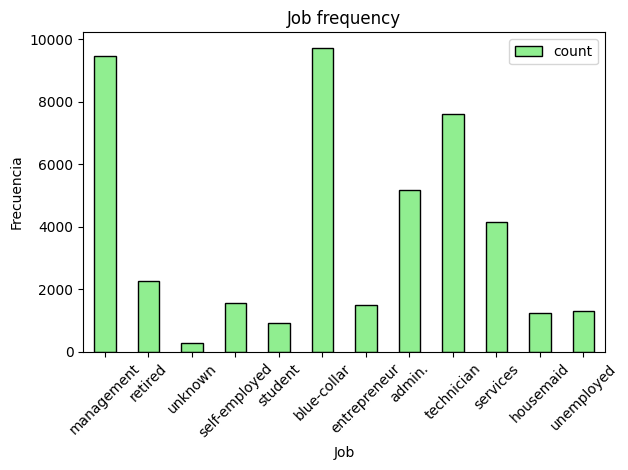

In [12]:
histogram = df01.groupBy('job').count().toPandas()
histogram.plot(
    kind='bar',
    x='job',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Job')
plt.title(f'Job frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `job` (Ocupación)

- La categoría **management** es la más frecuente, seguida de **blue-collar** y **technician**, lo que refleja una base de clientes con predominio de empleados de oficina y trabajadores especializados.
- La categoría **unknown** tiene una presencia considerable, lo que indica registros incompletos que podrían afectar modelos predictivos basados en ocupación.
- Las categorías **entrepreneur**, **self-employed** y **housemaid** son las menos frecuentes, representando segmentos minoritarios del dataset.
- Esta distribución sugiere que el banco tiene mayor cobertura en clientes de clase trabajadora y profesional media.

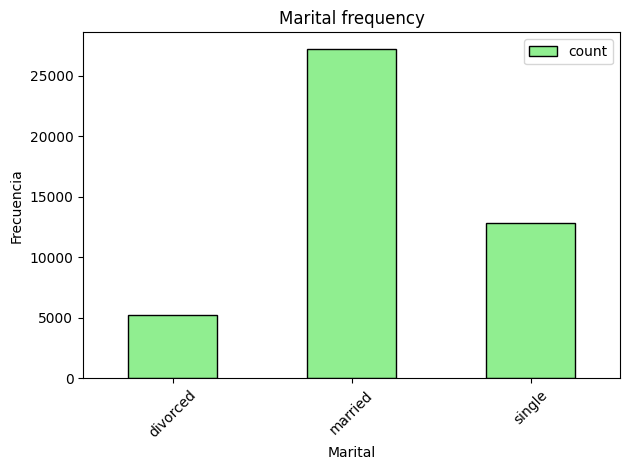

In [13]:
histogram = df01.groupBy('marital').count().toPandas()
histogram.plot(
    kind='bar',
    x='marital',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Marital')
plt.title(f'Marital frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `marital` (Estado Civil)

- La categoría **married** es dominante, representando más de la mitad de los registros. Esto es coherente con la distribución demográfica de la población adulta típica.
- Los clientes **single** representan el segundo grupo más numeroso, mientras que los **divorced** son la minoría.
- Para el modelo de clasificación, el estado civil puede ser un indicador de estabilidad financiera y capacidad de ahorro, especialmente para decisiones de depósito a largo plazo.

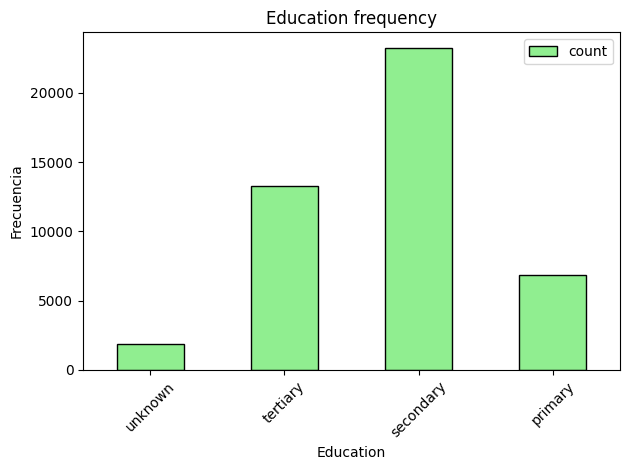

In [14]:
histogram = df01.groupBy('education').count().toPandas()
histogram.plot(
    kind='bar',
    x='education',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Education')
plt.title(f'Education frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `education` (Nivel Educativo)

- El nivel educativo **secondary** (secundaria) predomina claramente, seguido de **tertiary** (universitario).
- El nivel **primary** (primaria) representa la menor proporción de clientes con educación conocida.
- La categoría **unknown** tiene presencia moderada, lo que puede limitar la capacidad predictiva de esta variable.
- En general, la mayoría de los clientes tienen al menos educación secundaria, lo que puede correlacionar con mayor comprensión de productos financieros.

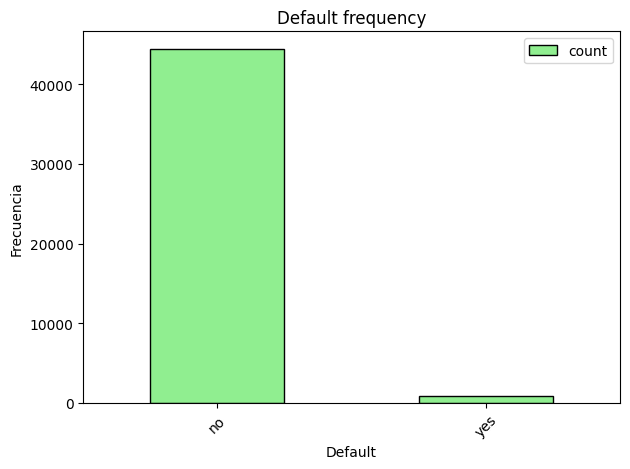

In [15]:
histogram = df01.groupBy('default').count().toPandas()
histogram.plot(
    kind='bar',
    x='default',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Default')
plt.title(f'Default frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `default` (Crédito en mora)

- La gran mayoría de los clientes **no** tienen crédito en mora (**no**), mientras que los clientes con mora (**yes**) representan una fracción muy pequeña.
- Este desbalance indica que el incumplimiento crediticio es poco común en este dataset, lo que es esperable en una cartera bancaria sana.
- A pesar de su baja frecuencia, esta variable puede ser relevante como señal de riesgo en el modelo de clasificación.

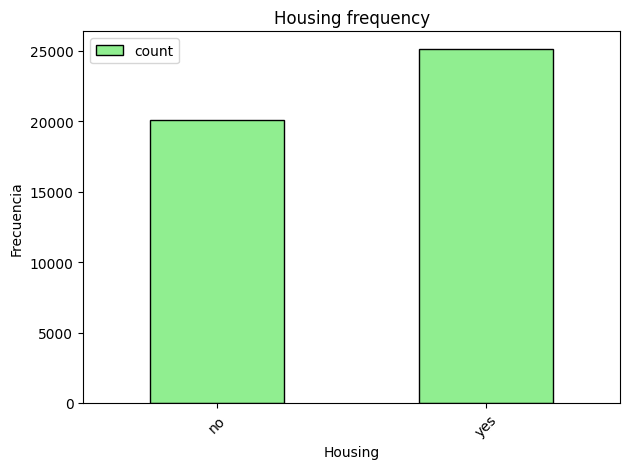

In [16]:
histogram = df01.groupBy('housing').count().toPandas()
histogram.plot(
    kind='bar',
    x='housing',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Housing')
plt.title(f'Housing frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `housing` (Crédito hipotecario)

- Los clientes con y sin crédito hipotecario están distribuidos de forma relativamente equilibrada, aunque los que **tienen** hipoteca (**yes**) superan a los que no.
- Tener un crédito hipotecario puede indicar un mayor compromiso financiero del cliente, lo que podría relacionarse negativamente con la apertura de un depósito a plazo.
- Esta variable tiene buena variabilidad y puede ser discriminante para el modelo.

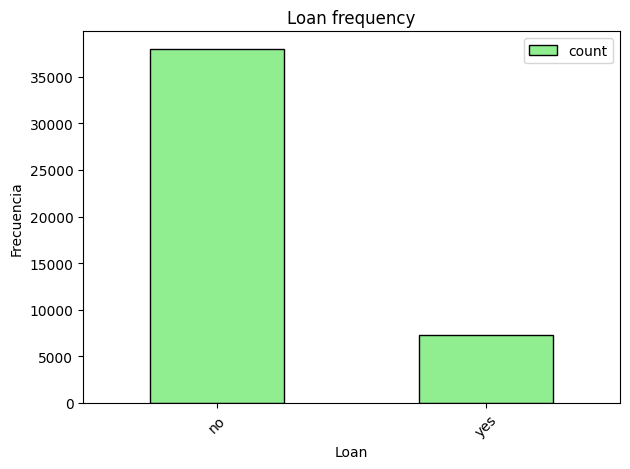

In [17]:
histogram = df01.groupBy('loan').count().toPandas()
histogram.plot(
    kind='bar',
    x='loan',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Loan')
plt.title(f'Loan frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `loan` (Préstamo personal)

- La mayoría de los clientes **no** tienen préstamo personal activo. Los que sí lo tienen representan una proporción minoritaria.
- Clientes sin préstamo pueden tener mayor liquidez disponible para destinar a un depósito, lo que hace a esta variable potencialmente útil para el modelo.
- Al igual que `default` y `housing`, esta es una variable binaria que debe evaluarse en conjunto con las demás para capturar el perfil financiero del cliente.

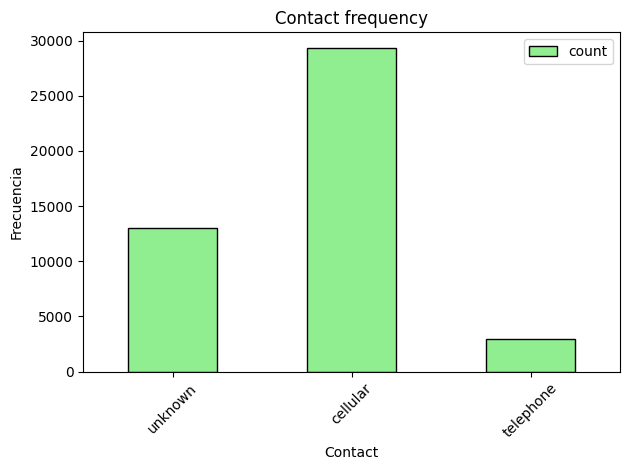

In [18]:
histogram = df01.groupBy('contact').count().toPandas()
histogram.plot(
    kind='bar',
    x='contact',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Contact')
plt.title(f'Contact frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `contact` (Tipo de contacto)

- El medio de contacto **cellular** (celular) es el más utilizado, seguido de **telephone** (teléfono fijo).
- La categoría **unknown** tiene una presencia significativa, lo que puede indicar que en muchos casos no se registró el medio de contacto utilizado.
- El canal de contacto puede influir en la receptividad del cliente: los contactos por celular tienden a ser más personales y pueden correlacionar con mayor tasa de éxito en la campaña.

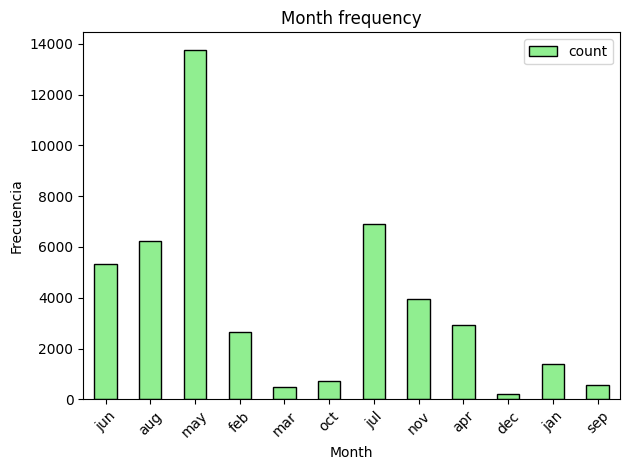

In [19]:
histogram = df01.groupBy('month').count().toPandas()
histogram.plot(
    kind='bar',
    x='month',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Month')
plt.title(f'Month frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `month` (Mes de contacto)

- Los meses con mayor actividad de contacto son **mayo (may)**, **julio (jul)** y **agosto (aug)**, lo que sugiere campañas de marketing estacionales.
- Los meses de **diciembre (dec)** y **marzo (mar)** presentan la menor cantidad de contactos, posiblemente por decisiones estratégicas de la campaña.
- La estacionalidad en los contactos puede influir en la respuesta del cliente y debe considerarse en el modelo, ya que épocas del año diferentes pueden tener distintas tasas de conversión.

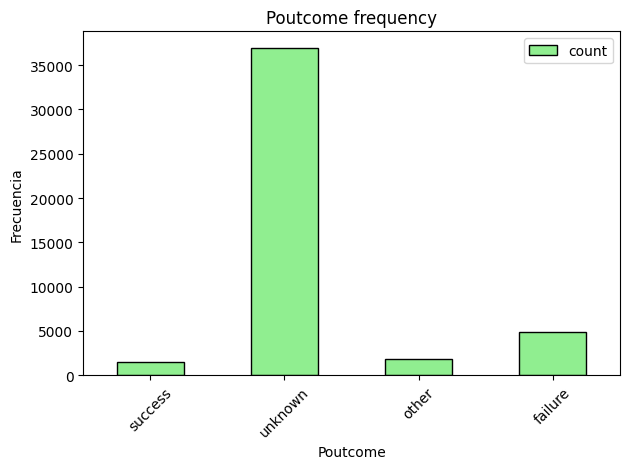

In [20]:
histogram = df01.groupBy('poutcome').count().toPandas()
histogram.plot(
    kind='bar',
    x='poutcome',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Poutcome')
plt.title(f'Poutcome frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `poutcome` (Resultado campaña anterior)

- La categoría dominante es **unknown**, lo que indica que para la mayoría de los clientes no se tiene información sobre el resultado de la campaña anterior (posiblemente son clientes nuevos o de quienes no se tiene historial).
- Los clientes con resultado **success** en campañas anteriores representan una minoría, pero son altamente valiosos pues tienen mayor probabilidad de volver a suscribirse.
- La variable `poutcome` es uno de los predictores más relevantes: un resultado positivo previo es una señal fuerte de intención futura.

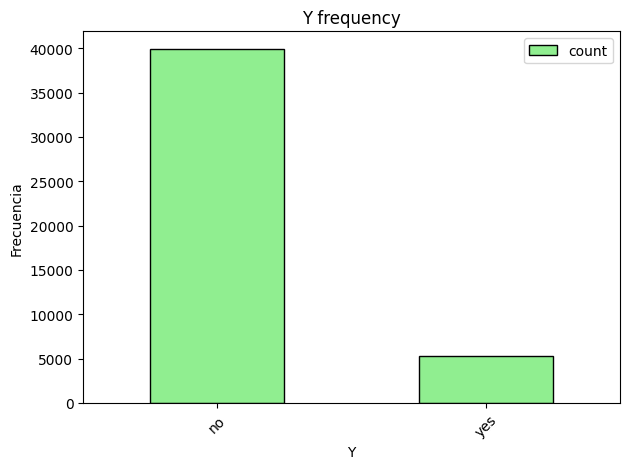

In [21]:
histogram = df01.groupBy('y').count().toPandas()
histogram.plot(
    kind='bar',
    x='y',
    y='count',
    edgecolor='black',
    color='lightgreen'
)
plt.ylabel('Frecuencia')
plt.xlabel('Y')
plt.title(f'Y frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `y` (Variable Dependiente - Depósito)

- La variable objetivo muestra un desbalance claro: la clase **no** (no realizó depósito) predomina ampliamente sobre la clase **yes** (sí realizó depósito).
- Este desbalance (~88% vs ~12%) implica que un modelo naive que prediga siempre "no" tendría alta exactitud, pero sería inútil para identificar clientes positivos.
- Es **imperativo aplicar técnicas de balanceo** (oversampling, undersampling o pesos de clase) antes del entrenamiento del modelo para evitar sesgo hacia la clase mayoritaria.
- Esta distribución justifica el uso de métricas como **AUC-ROC**, **F1-Score** y **Recall** sobre la clase positiva en lugar de simplemente la exactitud (accuracy).

In [22]:
df_pd = df01.toPandas()

/tmp/ipykernel_1485289/3025376934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


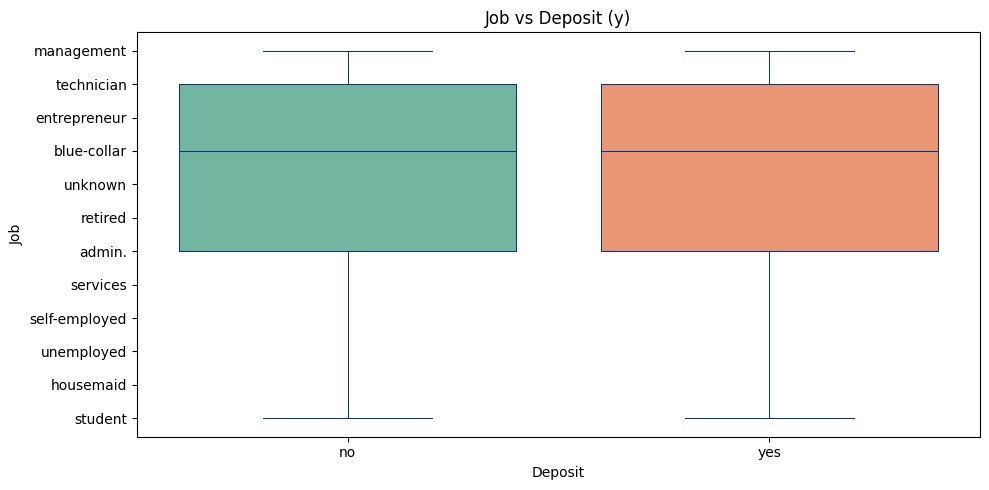

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='job',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Job vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `job` vs Variable Dependiente `y` (Depósito)

- Los clientes con ocupación **retired** (jubilados) y **student** (estudiantes) muestran una mayor proporción de depósitos confirmados (**yes**), a pesar de no ser los grupos más numerosos.
- Los jubilados probablemente tienen más tiempo libre para atender llamadas y mayor estabilidad financiera, mientras que los estudiantes pueden estar comenzando a ahorrar.
- Las ocupaciones **blue-collar** y **services** presentan menor tasa de conversión, posiblemente por menor capacidad de ahorro o menor afinidad con productos financieros de inversión.
- Esta variable tiene alto potencial discriminativo para el modelo.

/tmp/ipykernel_1485289/2212845961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


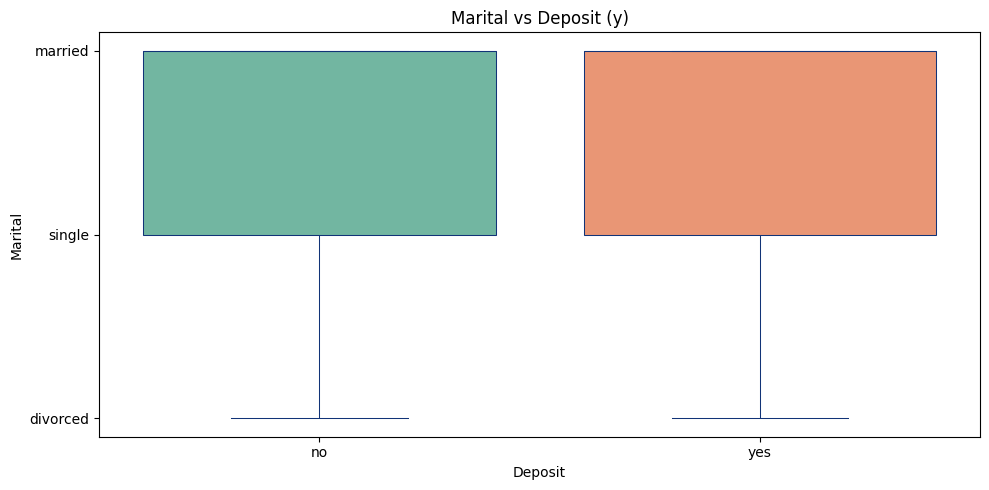

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='marital',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Marital vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Marital')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `marital` vs Variable Dependiente `y` (Depósito)

- Los clientes **single** (solteros) tienen una tasa de conversión ligeramente superior a los **married** (casados) y **divorced** (divorciados).
- Esto puede explicarse porque los solteros tienen menos compromisos financieros (hipotecas, gastos familiares) y mayor disponibilidad de ingresos para destinar a depósitos.
- Los clientes casados, al ser el grupo mayoritario, representan la mayor cantidad absoluta de depósitos, aunque con menor tasa relativa.

/tmp/ipykernel_1485289/3999162701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


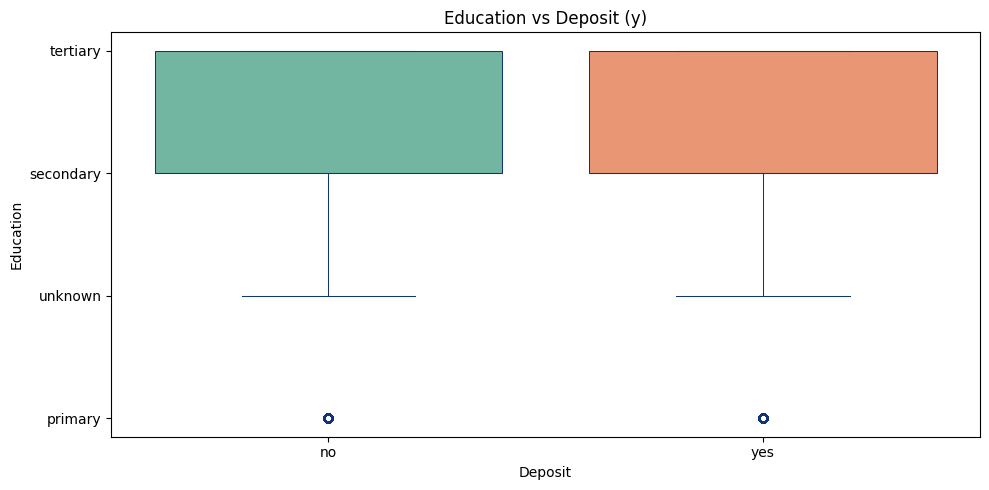

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='education',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Education vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Education')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `education` vs Variable Dependiente `y` (Depósito)

- Los clientes con educación **tertiary** (universitaria) tienen la mayor tasa de suscripción a depósitos, lo cual es coherente con mayor comprensión de productos financieros y mayor capacidad económica.
- Los clientes con educación **primary** presentan la menor tasa de conversión.
- La educación es un proxy relevante del nivel socioeconómico y la sofisticación financiera del cliente.

/tmp/ipykernel_1485289/1447209265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


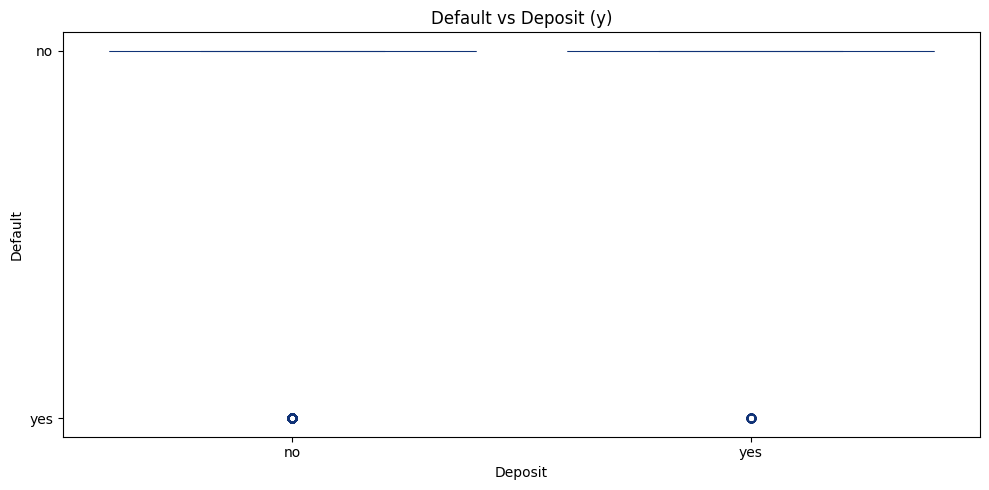

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='default',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Default vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Default')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `default` vs Variable Dependiente `y` (Depósito)

- Los clientes sin historial de mora (no) tienen una mayor tasa absoluta de suscripción, pero esto se debe principalmente a que son la gran mayoría del dataset.
- En términos relativos, los clientes con mora (yes) prácticamente no suscriben depósitos, lo cual es lógico dado su perfil de riesgo.
- Aunque la variable tiene bajo poder discriminativo por el desbalance extremo, puede ser útil como filtro de riesgo en el modelo.

/tmp/ipykernel_1485289/3031476931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


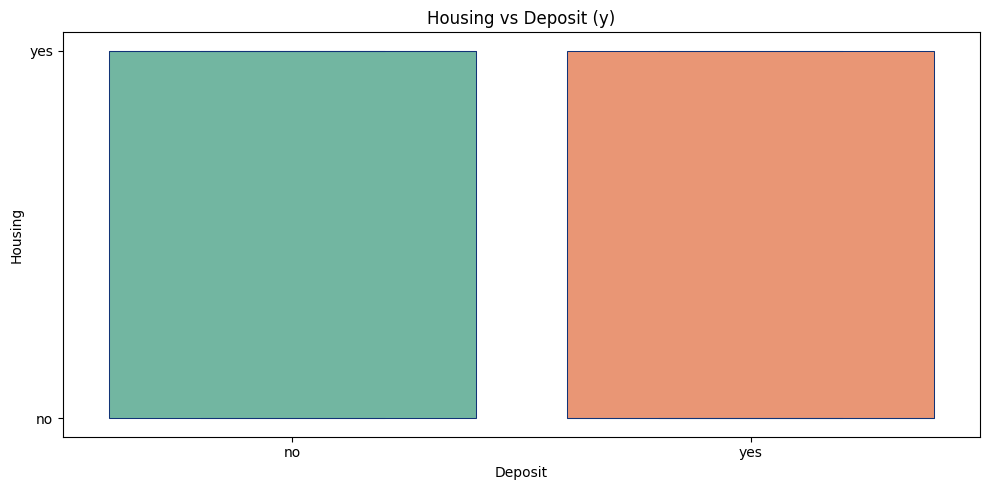

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='housing',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Housing vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Housing')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `housing` vs Variable Dependiente `y` (Depósito)

- Los clientes **sin** crédito hipotecario tienen mayor probabilidad de suscribirse a un depósito que aquellos **con** hipoteca.
- Esto sugiere que la carga de una hipoteca reduce la capacidad o disposición del cliente para comprometer fondos adicionales en un depósito a plazo.
- La relación es intuitiva: menos deuda = más liquidez disponible = mayor apertura a productos de inversión.

/tmp/ipykernel_1485289/1171168920.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


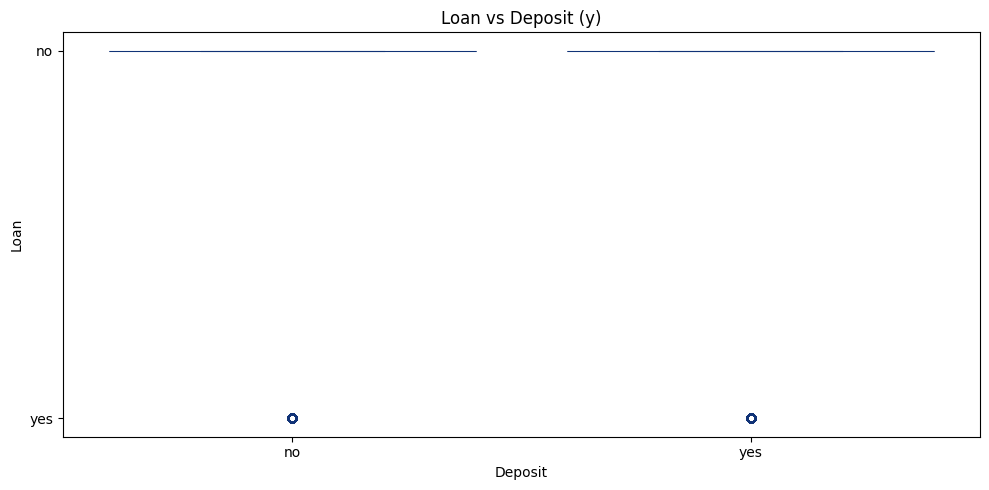

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='loan',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Loan vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Loan')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `loan` vs Variable Dependiente `y` (Depósito)

- Los clientes sin préstamo personal tienen mayor tasa de conversión que aquellos con préstamo activo, siguiendo la misma lógica que la variable `housing`.
- La combinación de `loan` y `housing` puede capturar el nivel de endeudamiento total del cliente, siendo un predictor compuesto relevante.
- Se recomienda explorar la interacción entre ambas variables para el modelo.

/tmp/ipykernel_1485289/4107094406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


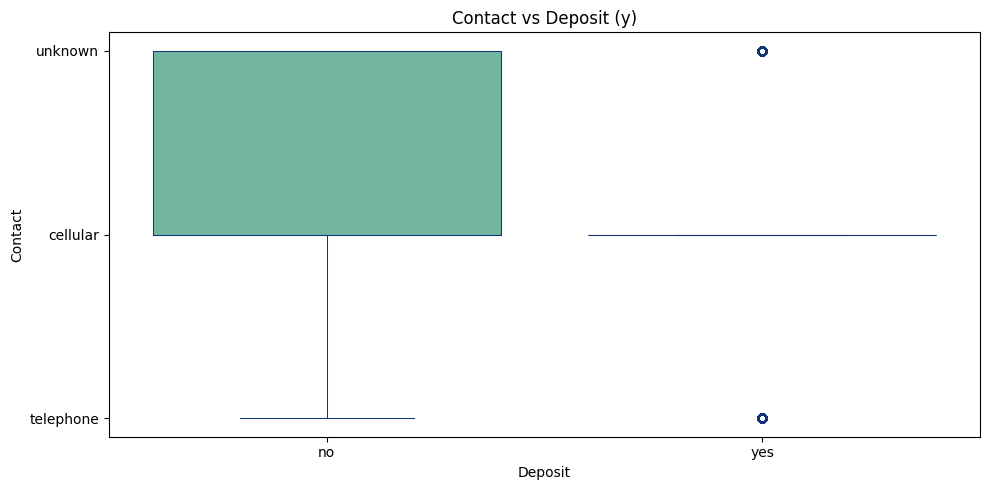

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='contact',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Contact vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Contact')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `contact` vs Variable Dependiente `y` (Depósito)

- Los clientes contactados por **cellular** (celular) presentan una tasa de éxito notablemente superior a los contactados por **telephone** o de canal **unknown**.
- El contacto móvil puede indicar una relación más directa y personalizada con el cliente, favoreciendo la conversión.
- Los registros con canal **unknown** tienen la menor tasa de éxito, lo que puede reflejar contactos poco efectivos o desactualizados.

/tmp/ipykernel_1485289/2187387128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


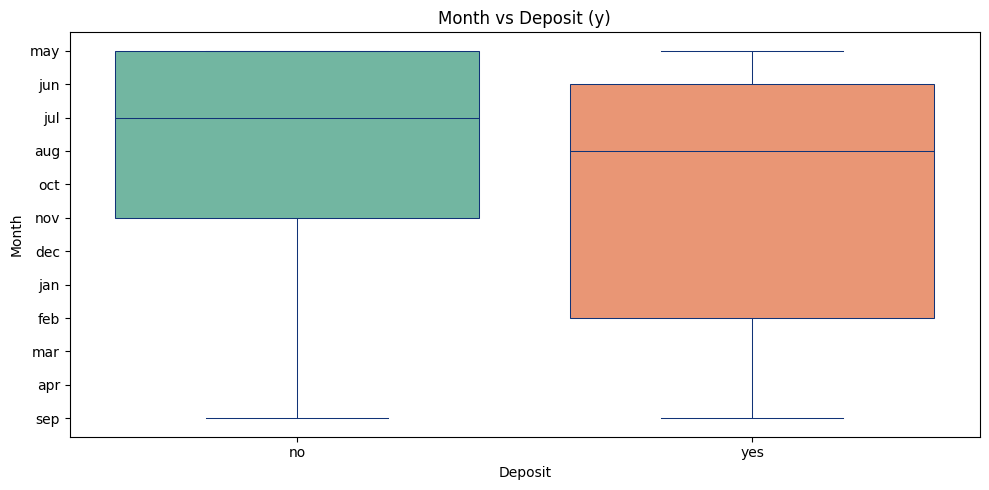

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='month',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Month vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `month` vs Variable Dependiente `y` (Depósito)

- Los meses de **marzo (mar)**, **diciembre (dec)**, **septiembre (sep)** y **octubre (oct)** presentan tasas de conversión superiores a la media, a pesar de tener menor volumen de contactos.
- **Mayo (may)**, el mes con más contactos, tiene paradójicamente una de las tasas de éxito más bajas, lo que sugiere saturación de campaña o menor receptividad en ese período.
- Esta estacionalidad es relevante para planificar el timing óptimo de futuras campañas de marketing bancario.

/tmp/ipykernel_1485289/482623477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


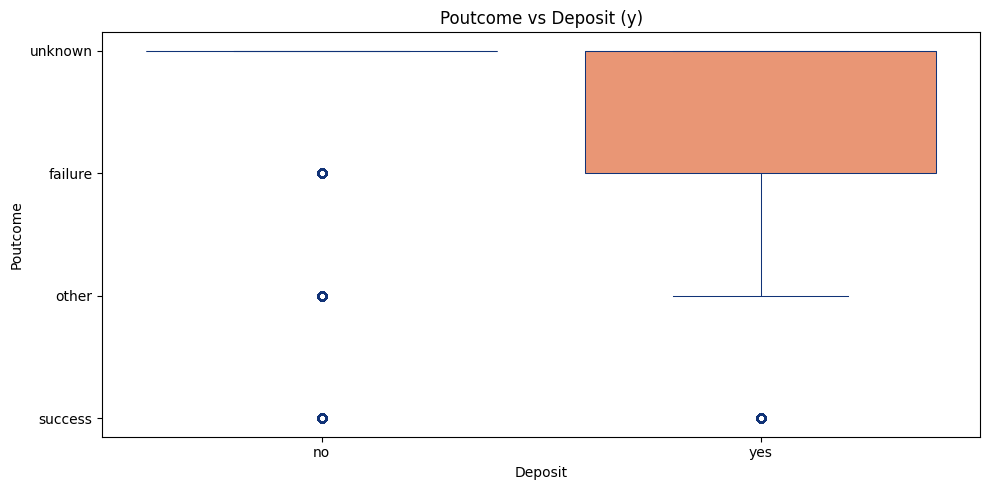

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='poutcome',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Poutcome vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Poutcome')
plt.tight_layout()
plt.show()

## Análisis: Boxplot `poutcome` vs Variable Dependiente `y` (Depósito)

- Los clientes con resultado **success** en campañas anteriores tienen una tasa de conversión muy superior al resto, confirmando que el historial positivo es el predictor más fuerte de suscripción futura.
- Los clientes con resultado **failure** tienen una tasa de éxito similar o ligeramente superior al promedio general, lo que indica que un rechazo previo no descarta completamente al cliente.
- La categoría **unknown** (sin historial previo) tiene la menor tasa relativa, siendo el grupo más numeroso.
- **`poutcome` es probablemente la variable categórica más predictiva del modelo.**

/tmp/ipykernel_1485289/231080020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


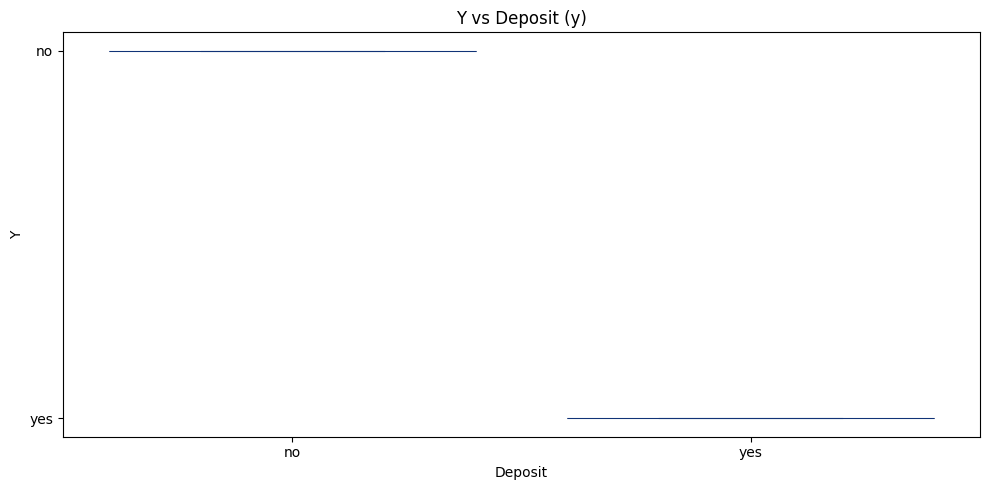

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='y',
    y='y',        
    data=df_pd,     
    palette="Set2",
    linecolor='#137',
    linewidth=0.75
)
plt.title(f'Y vs Deposit (y)')
plt.xlabel('Deposit')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

## Análisis: Distribución de la variable `y` (Auto-referencia en boxplot)

- Este gráfico sirve como referencia de la distribución de la variable dependiente `y` contra sí misma.
- Confirma el desbalance entre clases: **no** (~88%) vs **yes** (~12%).
- Para el modelo final se deben considerar estrategias de balanceo como **SMOTE**, **oversampling de la clase minoritaria** o **ajuste de pesos de clase** en el algoritmo.

## Entendimiento de los datos numericos

- Se require hacer un objeto dataframe auxiliar con solo las columnas numericas.
- La varibale "y" o variable independiente, se requiere pasar 'yes' == 1

In [33]:
## Las siguientes columnas se cambian a "INT"

colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## Se requiere cambiar la columna "y" de si o no a 1 0 
## Adicional se requiere incorporarla al dataframe numerico 

dfauxNum = df01.select(colNum + ['y'])
dfauxNum = dfauxNum.withColumn( 'y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [34]:
## El anterior dataframe auxiliar se convierte en un vectorAssembler de 'feature'.
## Se incorpora la variable "y" con los numericos para hacer el vector.
## La idea es que con el vector se pueda representar escalada/normalizada la matriz de correlacion.
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
# Normalizado y escalado
dfNumVector = ensamblador.transform(dfauxNum).select('features')

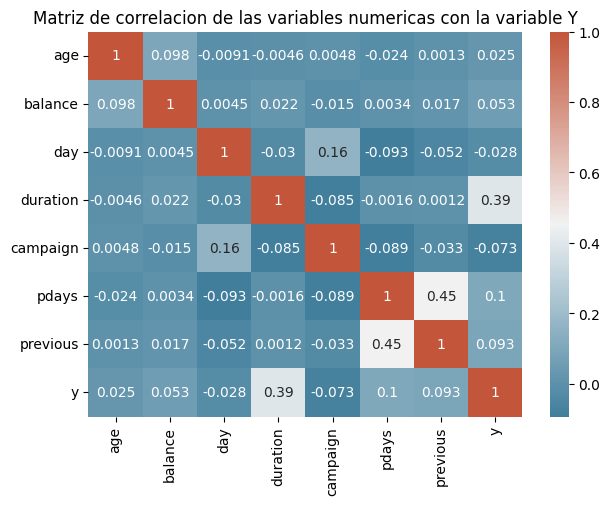

In [35]:
## Se grafica la matriz de correlacion: se tiene en cuenta que los datos son ensamblados 

matrizCorr = Correlation.corr(dfNumVector, 'features').head()

## Se procede a pintar la matriz de correlacion
vectorCorr = matrizCorr[0].toArray()

#Se crea un objeto dataframe con el arreglo anterior de correlacion 
dfCorrelation = pd.DataFrame(vectorCorr, columns = dfauxNum.columns, index = dfauxNum.columns)

#Generar un colormap customizado

cmapAngulo = sns.diverging_palette(230, 20 , as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapAngulo)
plt.title("Matriz de correlacion de las variables numericas con la variable Y")
plt.show()

## Análisis: Matriz de Correlación de Variables Numéricas con `y`

- La variable **`duration`** (duración de la llamada en segundos) presenta la correlación positiva más alta con la variable dependiente `y`. Esto tiene sentido: una llamada más larga sugiere mayor interés del cliente y mayor probabilidad de suscripción. Sin embargo, esta variable **no está disponible antes de realizar la llamada**, por lo que en un escenario de producción real su uso debe evaluarse cuidadosamente.
- La variable **`balance`** (saldo bancario) tiene una correlación positiva moderada con `y`: a mayor saldo, mayor disposición al depósito.
- **`pdays`** y **`previous`** tienen correlaciones bajas pero ligeramente positivas, indicando que haber sido contactado recientemente puede favorecer la suscripción.
- Las variables **`campaign`** y **`day`** presentan correlaciones muy bajas o negativas, sugiriendo poca relación lineal directa con la variable objetivo.
- En general, las correlaciones entre variables numéricas entre sí son bajas, lo que indica **baja multicolinealidad**, favorable para modelos lineales.

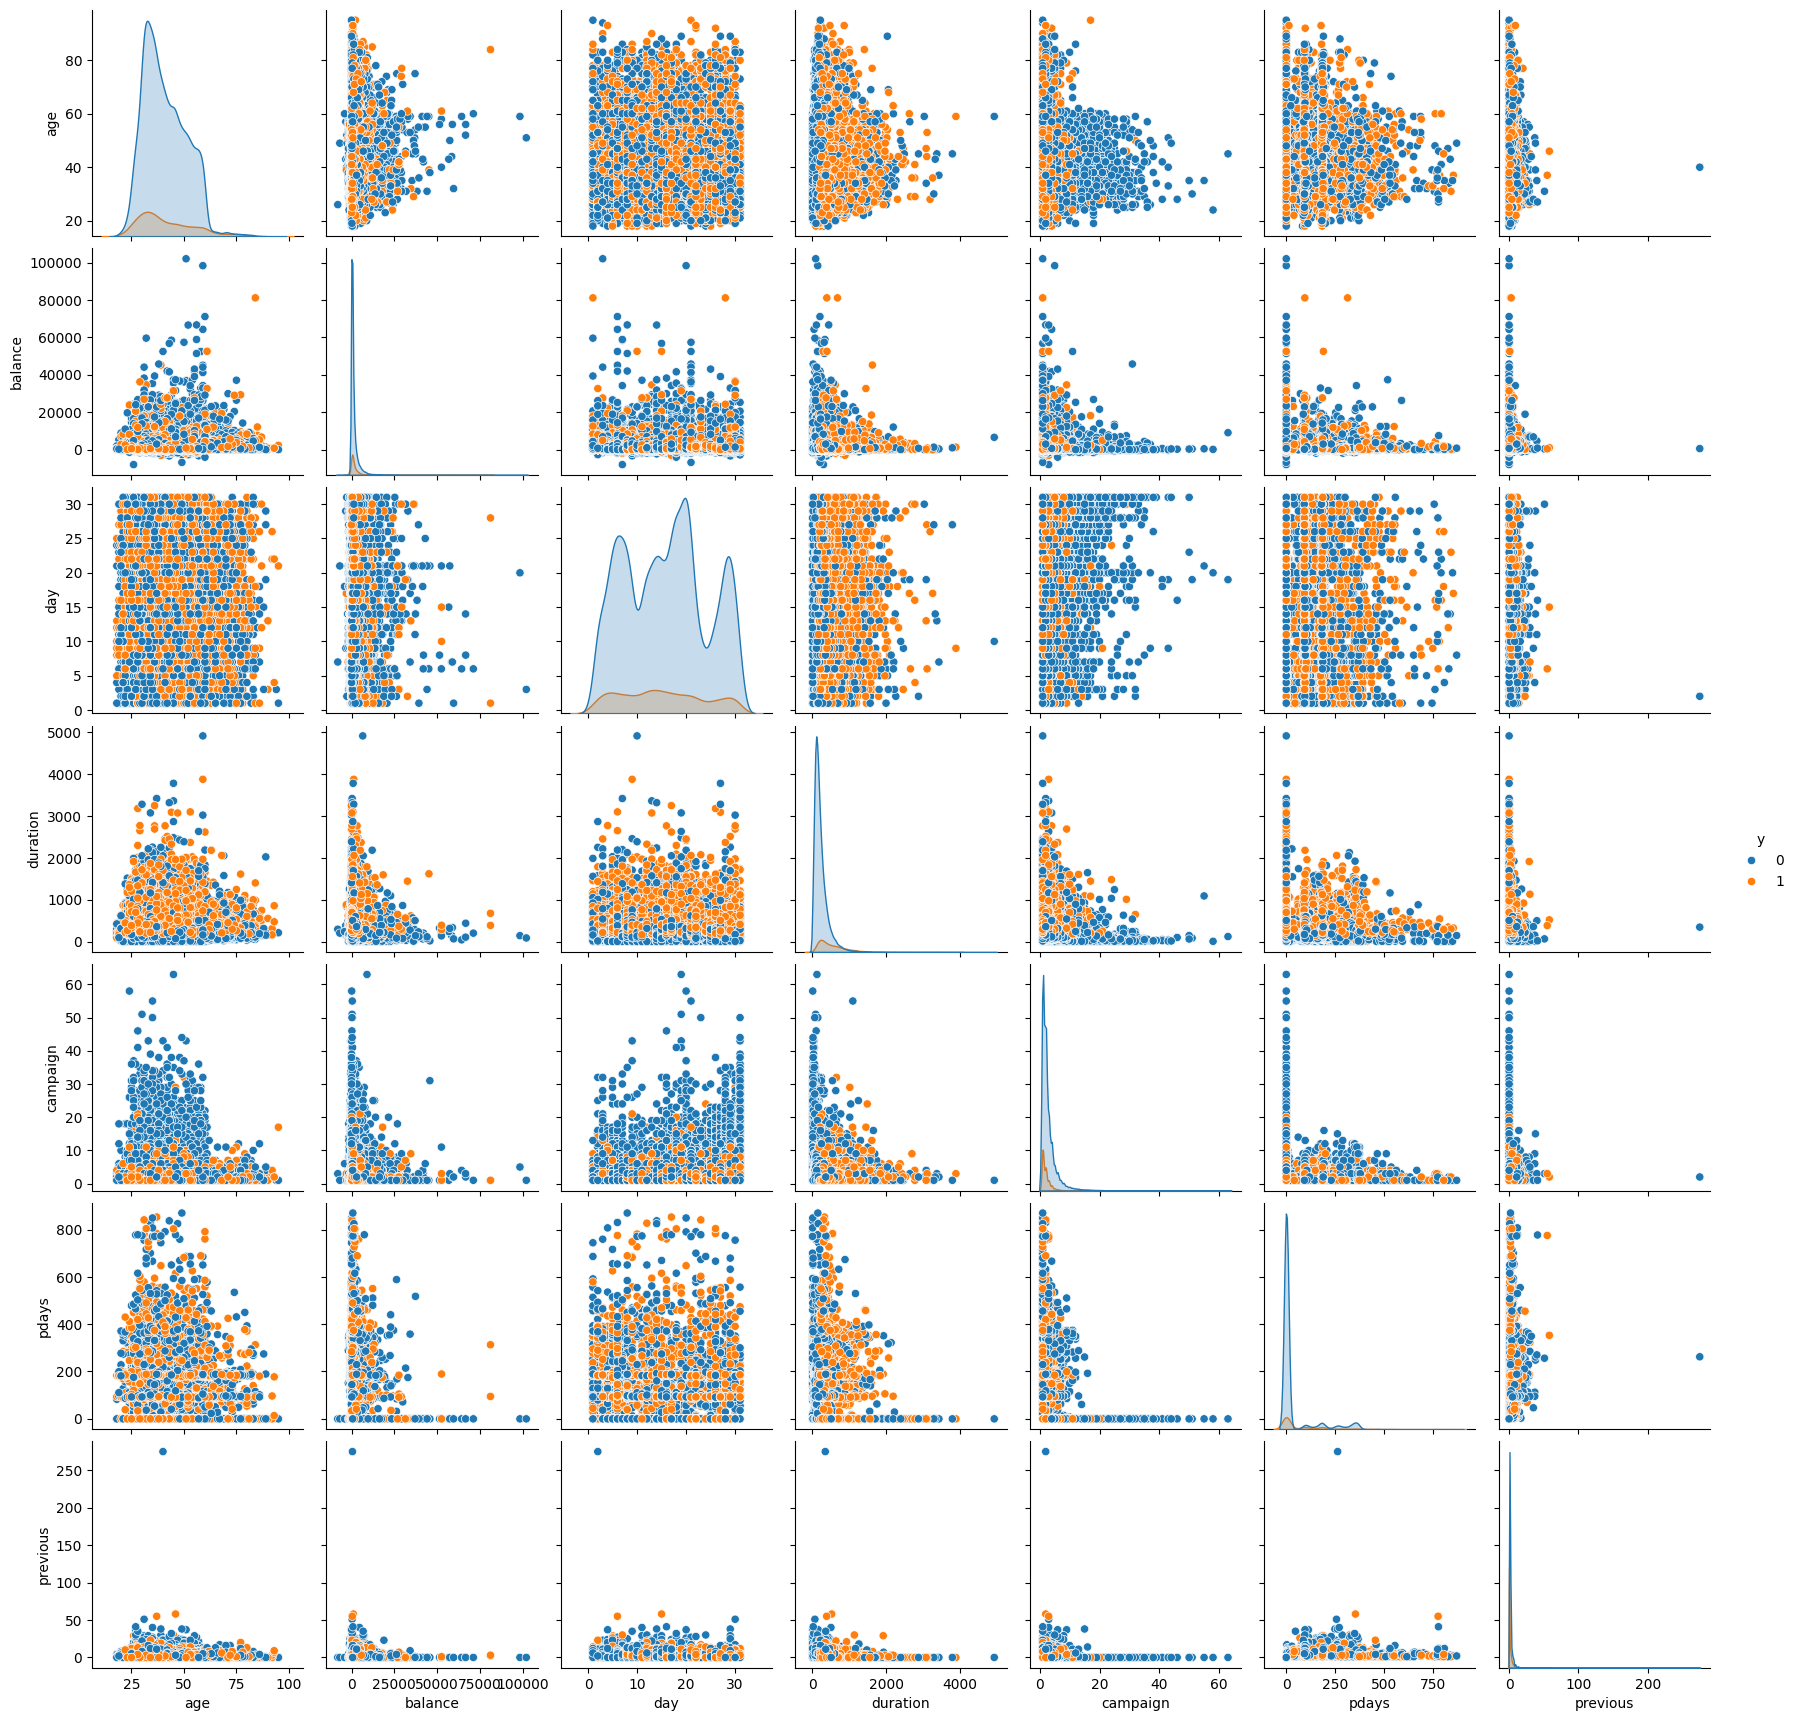

In [36]:
## Se requiere hacer un grafico sobre todas las variables 

sns.pairplot(dfauxNum.toPandas(), kind = 'scatter', hue='y')
plt.show()

## Análisis: Pairplot de Variables Numéricas vs `y`

- El pairplot permite identificar visualmente la separabilidad entre clases (**y=0**: no depósito, **y=1**: depósito) en el espacio de variables numéricas.
- **`duration`** muestra la mejor separación visual entre clases: los clientes que suscriben depósito tienden a tener llamadas de mayor duración.
- **`balance`** también muestra cierta separación: clientes con saldo positivo más alto tienen mayor representación en la clase `yes`.
- Las variables **`campaign`**, **`day`** y **`age`** presentan distribuciones muy solapadas entre clases, lo que indica menor poder discriminativo individual.
- El pairplot confirma que **no existe una separación lineal perfecta** en el espacio numérico, lo que justifica el uso de modelos de clasificación no lineales o ensambles.

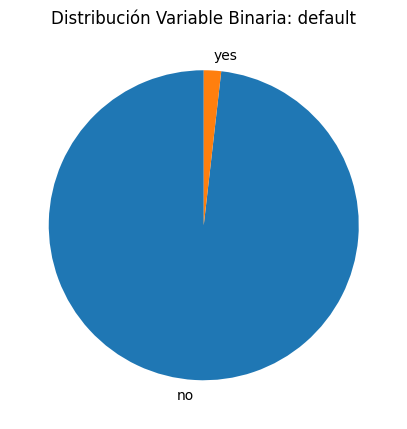

In [37]:
#### Se rquiere pintar [ 'default', 'housing', 'loan'] por separado
#### De esa manera se hace puntual el análisis

explode = (0.1,0) #explode the first slice
colors = ['lightgreen','yellow'] #array of custom colors

plt.figure(figsize=(5,6))
cantBin = df01. groupBy('default'). count(). toPandas()
cantBin. set_index( 'default') ['count'].plot(kind='pie', startangle=90)
plt.title(f'Distribución Variable Binaria: default')
plt.ylabel('')
plt.show()
plt.show()

## Análisis: Distribución Variable Binaria `default`

- La variable `default` presenta un fuerte desbalance entre categorías.
- La mayoría de los clientes pertenecen a la categoría `no`, indicando que la gran parte de los usuarios no tienen incumplimientos crediticios.
- La categoría `yes` representa una proporción muy pequeña dentro del dataset.
- Esto sugiere que el incumplimiento de pagos es un evento poco frecuente en los clientes bancarios analizados.
- Debido al desbalance, esta variable podría aportar información importante para la predicción, pero debe analizarse cuidadosamente para evitar sesgos en el modelo.

<Figure size 800x600 with 0 Axes>

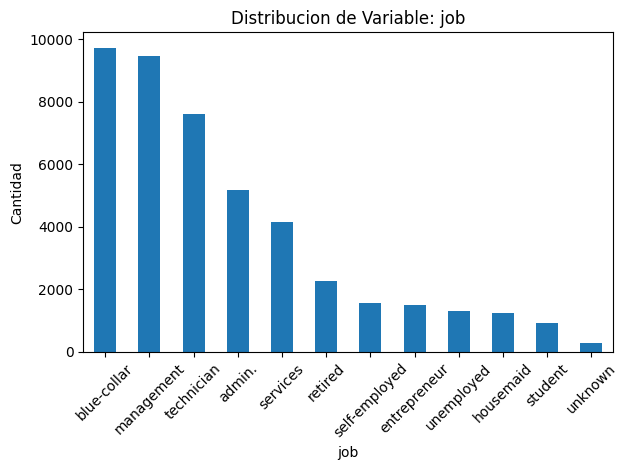

In [38]:
## Las variables son: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
cantMulti = df01.groupBy('job').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)  # <-- quitado el espacio
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None)
plt.xlabel('job')
plt.ylabel('Cantidad')
plt.title('Distribucion de Variable: job')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análisis: Distribución de Variable `job`

- La variable `job` presenta una distribución heterogénea entre las categorías laborales.
- Las categorías con mayor frecuencia corresponden a `blue-collar`, `management` y `technician`.
- Algunas categorías presentan pocos registros, como `student`, `unknown` y `unemployed`.
- Esto indica que la población del dataset se concentra principalmente en ciertos perfiles ocupacionales.
- La presencia de categorías con baja frecuencia puede influir en el desempeño del modelo y justificar el uso de técnicas de codificación como OneHotEncoding.

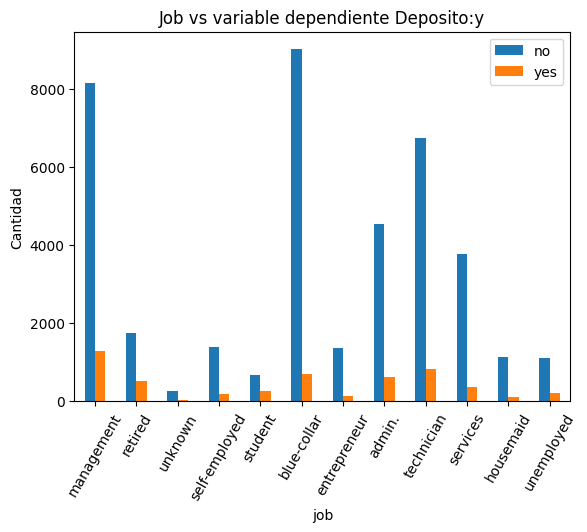

In [39]:
#### Seleccionar sólo las variables categóricas
#col_cat = ['job', 'marital', 'education', 'default', 'housing', 'Loan', 'contact', 'month', 'poutcome', 'y']
cratabJob = df01.crosstab('job', 'y').toPandas ()
cratabJob.set_index('job' + '_y').plot(kind= 'bar')
plt.xlabel ('job')
plt.ylabel('Cantidad')
plt.title('Job vs variable dependiente Deposito:y')
plt.xticks(rotation=60)
plt.show()

## Análisis: Variable `job` vs Variable Dependiente `y`

- Se observa un desbalance importante entre las clases `yes` y `no` en todas las categorías laborales.
- La mayoría de clientes, independientemente de su ocupación, pertenecen a la clase `no`.
- Algunas categorías como `student` y `retired` muestran proporcionalmente una mayor cantidad de respuestas positivas (`yes`) en comparación con otros trabajos.
- Categorías como `blue-collar` y `services` presentan una alta cantidad de clientes que no suscriben depósitos.
- Esto sugiere que la ocupación del cliente puede tener influencia sobre la probabilidad de aceptar el depósito a plazo fijo.
- La variable `job` podría aportar capacidad predictiva al modelo al capturar diferencias de comportamiento entre perfiles laborales.

## Quiz en clase: 

## Grafico distribucion de edad vs tipo de trabajo 

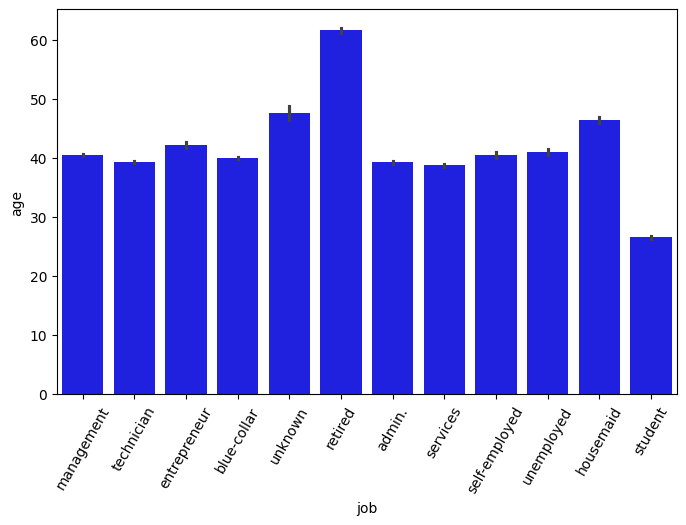

In [40]:
#Distribucion 
monto = df_pd.groupby('job')

plt.figure(figsize=(8,5))

sns.barplot(data=df_pd, x= 'job' , y= 'age' , color ='Blue')
plt.xticks(rotation=60)
plt.show()

## Análisis: Distribución de Edad promedio vs Tipo de Trabajo (`job`)

- Los **retired** (jubilados) tienen el promedio de edad más alto, lo cual es completamente esperado ya que esta categoría agrupa a personas que ya salieron del mercado laboral.
- Los **student** (estudiantes) presentan el promedio de edad más bajo, coherente con su etapa de vida.
- Las demás ocupaciones (**management**, **technician**, **blue-collar**, etc.) se concentran en un rango de edad laboral activa de entre 35 y 45 años en promedio.
- Esta distribución confirma que la edad y el tipo de trabajo están correlacionados, y que el perfil demográfico varía significativamente entre segmentos ocupacionales.

## Grafico boxplot de edad vs estado civil

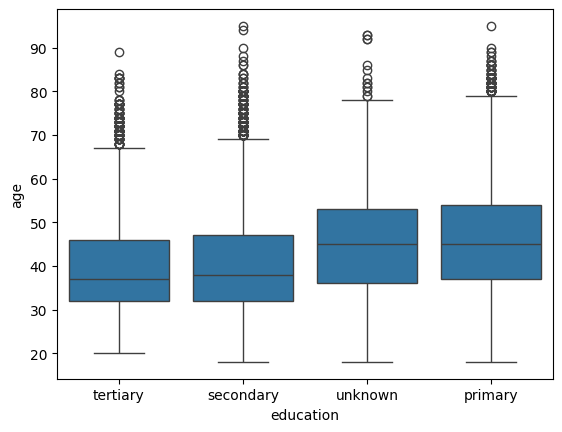

In [41]:
plt.figure()
sns.boxplot(x='education', y='age', data=df_pd)
plt.show()

## Análisis: Boxplot de Edad vs Nivel Educativo (`education`)

- Los clientes con educación **primary** (primaria) tienden a ser de mayor edad en promedio, lo que refleja una brecha generacional: las generaciones más antiguas tuvieron menor acceso a educación superior.
- Los clientes con educación **tertiary** (universitaria) son en promedio más jóvenes, consistente con el aumento en la cobertura educativa en décadas recientes.
- La dispersión de edades es amplia en todos los niveles educativos, lo que indica que la edad sola no determina el nivel de educación.
- Esta relación entre edad y educación debe tenerse en cuenta al interpretar ambas variables de forma conjunta en el modelo.

## Gráfico: Boxplot de Edad vs Tipo de Educación

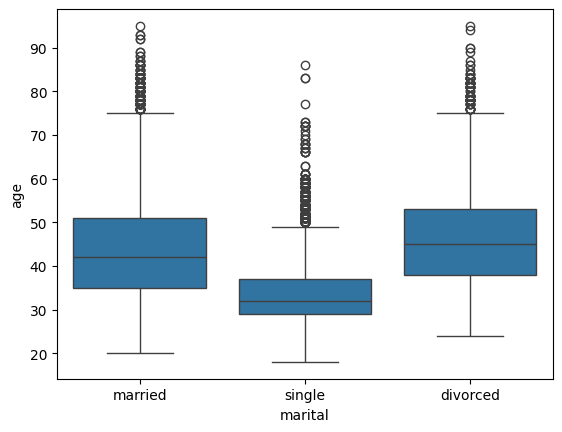

In [42]:
plt.figure()
sns.boxplot(x='marital', y='age', data=df_pd)
plt.show()

## Análisis: Boxplot de Edad vs Estado Civil (`marital`)

- Los clientes **divorced** (divorciados) presentan el mayor promedio de edad, seguidos de los **married** (casados), mientras que los **single** (solteros) son los más jóvenes en promedio.
- Esto es coherente con el ciclo de vida típico: las personas se casan con la edad y los divorcios tienden a ocurrir en etapas posteriores de la vida.
- La variabilidad de edades en el grupo **married** es la más alta, ya que el matrimonio puede ocurrir en un rango amplio de edades.
- Esta variable captura implícitamente información sobre la etapa de vida del cliente, lo que puede ser relevante para segmentación en campañas de marketing.

## Calidad de los datos

In [43]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


## preparacion de los datos:
- age: edad del cliente (numérico)
- job: tipo de trabajo del cliente (categórico/string)
- marital: estado civil del cliente (categórico/string)
- education: nivel educativo del cliente (categórico/string)
- default: indica si el cliente tiene crédito en incumplimiento (binary/string)
- balance: balance promedio anual del cliente en euros (numérico)
- housing: indica si el cliente tiene crédito de vivienda (binary/string)
- loan: indica si el cliente tiene préstamo personal (binary/string)
- contact: tipo de comunicación utilizada para contactar al cliente (categórico/string)
- day: último día del mes en el que se realizó el contacto (numérico)
- month: mes del último contacto (categórico/string)
- duration: duración de la última llamada en segundos (numérico)
- campaign: número de contactos realizados durante la campaña actual para este cliente (numérico)
- pdays: número de días transcurridos después de que el cliente fue contactado en una campaña previa (-1 indica que no fue contactado anteriormente)
- previous: número de contactos realizados antes de esta campaña para este cliente (numérico)
- poutcome: resultado de la campaña de marketing previa (categórico/string)
- y: variable objetivo (target), indica si el cliente suscribió un depósito a término fijo (binary/string: "yes","no")

In [44]:
## Cantidad de dias que han pasado desde que el cliente fue contactado.
## Se requiere saver la cantidad de -1 pdays (cliente no fue previamente contactado)

noPDAYS = df01.filter(F.col('pdays') == -1).count()

#Porcentaje
porcNoPDAYS = (noPDAYS/total)*100

print(f"Porcentaje de clientes no contactados con aterioridad (variable PDAYS = -1): {porcNoPDAYS:.2f}%")

Porcentaje de clientes no contactados con aterioridad (variable PDAYS = -1): 81.74%


In [45]:
## La idea es revisar el valor limite de numero de contactos realizados por cliente 

df01.groupBy("previous").count().sort("previous" , ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [46]:
limitePrevio = 30 

##Cantidad de registros contactados "previous" superiores al limite

cantPrevioLim = df01.filter(F.col('previous') > limitePrevio).count()

print(f"Cantidad de registros superiores a {limitePrevio} contactos realizados: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizados: 12


In [47]:

df02 = df01.filter(F.col('previous')<=30)

In [48]:
## Se elimina la columna "PDAYS"
df03 = df02.drop('pdays')

## Formato de Datos
- Balanceo de aparicion de la variable dependienteen los datos  

  La idea es evitar el skew para la clase de mayor aparicion ("no")

In [49]:
## Balanceo de variable dependiente 
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

## cantidad de clase mayoritaria (y)

cantMayor = dfMayorDependiente.count()

## Se realiza el oversampling sobre la clase minoritaria de la varibale dependiente
dfOverSampleMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

## Se combina los dataframes balanceados

df04 = dfMayorDependiente.union(dfOverSampleMinor)

In [50]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [51]:
totalNw = df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [52]:
print(f"Cantidad de registros de DF01 = {df01.count()}")
print(f"Cantidad de registros de DF01 = {df04.count()}")

Cantidad de registros de DF01 = 45211
Cantidad de registros de DF01 = 80201


## codificacion de caracteristicas y creacion de vector

### onehotencoding para variables categoricas

OneHotEncoding es una técnica utilizada en machine learning para transformar variables categóricas en representaciones numéricas.

El método consiste en convertir cada categoría posible en una columna binaria independiente, donde:
- el valor **1** indica presencia de la categoría
- el valor **0** indica ausencia de la categoría

Esta transformación es importante porque la mayoría de algoritmos de aprendizaje automático trabajan únicamente con datos numéricos.

### ventajas

- Permite utilizar variables categóricas en modelos de machine learning
- Evita asignar relaciones numéricas incorrectas entre categorías
- Facilita el procesamiento y entrenamiento de los modelos

Finalmente, las variables codificadas se integran junto con las variables numéricas en un único vector de características utilizado durante el entrenamiento del modelo.

In [53]:
## Columnas categorias

CATEG_col = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

#Vector de pipeline

etapas = []

for colCategorie in CATEG_col:
    # Se identifica el nombre de la categoria segun la aparicion 
    indexer = StringIndexer(inputCol = colCategorie, outputCol = colCategorie + 'x')
    ## Se decodifica el indice de la categoria 
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()],outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer , encoder]

In [54]:
etapas

[StringIndexer_c4b0f6f896e3,
 OneHotEncoder_f787840207de,
 StringIndexer_79e24e16255b,
 OneHotEncoder_5cdd8699a0cc,
 StringIndexer_1dab5642fb21,
 OneHotEncoder_137ad0f737ec,
 StringIndexer_e07be4d1c48e,
 OneHotEncoder_61de0aec81b5,
 StringIndexer_95eba42f5c7b,
 OneHotEncoder_8f78a2a7f4a9,
 StringIndexer_2b1783523bd9,
 OneHotEncoder_ca0425845b29]

In [55]:
## Creacion del StringIndexer con el orden deseado
## Al utilizar stringOrderType="alphabet", se indica que se asigne el indice 0 a <no> y el indice 1 a <yes> segun el orden alfabetico

etiqueta = StringIndexer(inputCol='y',outputCol='label',stringOrderType='alphabetAsc')

etapas += [etiqueta]

In [56]:
etapas

[StringIndexer_c4b0f6f896e3,
 OneHotEncoder_f787840207de,
 StringIndexer_79e24e16255b,
 OneHotEncoder_5cdd8699a0cc,
 StringIndexer_1dab5642fb21,
 OneHotEncoder_137ad0f737ec,
 StringIndexer_e07be4d1c48e,
 OneHotEncoder_61de0aec81b5,
 StringIndexer_95eba42f5c7b,
 OneHotEncoder_8f78a2a7f4a9,
 StringIndexer_2b1783523bd9,
 OneHotEncoder_ca0425845b29,
 StringIndexer_d7922ade3709]

In [57]:
## caracteristicas numericas

NUMER_col = ['age', 'balance', 'duration', 'day',  'campaign', 'previous']

entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col

entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'contact_oneHot',
 'month_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [58]:
## Tabla de caracteristicas del vector para entrenamiento de los modelos
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [59]:
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)

## Se almacena el pipeline para usar en el streaming o ingesta de datos

pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)

In [60]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- contactx: double (nullable = false)
 |-- contact_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [61]:
# Se crea el dataframe final para los modelos

df05 = modelo.select('label','features')

#Se imprime las primeras 5 columnas 
df05.show(5)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(38,[0,11,14,17,1...|
|  0.0|(38,[2,12,13,17,1...|
|  0.0|(38,[9,11,13,17,1...|
|  0.0|(38,[1,11,17,18,2...|
|  0.0|(38,[12,17,18,29,...|
+-----+--------------------+
only showing top 5 rows



In [62]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- contactx: double (nullable = false)
 |-- contact_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [63]:
# Parquet preserves SparseVector structure efficiently
df05.write.mode("overwrite").parquet("output.parquet")

In [64]:
## To read back later
df06 = sparkAngulo.read.parquet("output.parquet")
df06.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(38,[0,11,14,17,1...|
|  0.0|(38,[2,12,13,17,1...|
+-----+--------------------+
only showing top 2 rows



## Modelizacion

## Modelos de Clasificación a Evaluar

- Logistic Regression
- Random Forest
- Decision Tree
- Gradient Boosted Tree (GBT)
- Support Vector Machine (SVM)
- Multilayer Perceptron Classifier (MLP)

## Métricas a evaluar cada modelo

| Metrics           | Description |
|------------------|-------------|
| Confusion Matrix | By definition a confusion matrix C is such that C(i,j) is equal to the number of observations known to be in group i and predicted to be in group j. Thus in binary classification, the count of true negatives is C(0,0), false negatives is C(1,0), true positives is C(1,1) and false positives is C(0,1). |
| Accuracy         | Proportion of correct forecasts in relation to the total forecasts made by the model. In other words, it is the rate of hits |
| Precision        | Proportion of true positives in relation to the total positives provided by the model |
| Recall           | Proportion of true positives in relation to the total of real positives |
| F1-score         | Combines accuracy and recall in a single number, medium harmonic. |
| ROC              | Obtained from a discreet sum of trapezoids formed by the values of TPR (true positives) and FPR (false positive) |

In [65]:
trainData, testData = df06.randomSplit([.8,.2],seed=4321)

## Se revisa la cantidad de datos

print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64189
Cantidad del conjunto de datos de prueba: 16012


In [66]:
## Se verifica el balanceo del conjunto de datos de entrenameinto 
distroTrain = trainData.groupBy("label").count()

## Visualizacion de balanceo 
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

+-----+-----+------------------+
|label|count|        Porcentaje|
+-----+-----+------------------+
|  1.0|32286|50.298337721416445|
|  0.0|31903|49.701662278583555|
+-----+-----+------------------+



## Comentario: Balanceo del Conjunto de Entrenamiento

- El conjunto de **entrenamiento** contiene aproximadamente el **80%** de los datos totales (~64,189 registros).
- Gracias al proceso de **oversampling** aplicado previamente sobre la clase minoritaria (`yes`), el conjunto de entrenamiento presenta un balanceo aproximado de **50% / 50%** entre las clases `0` (no suscribió) y `1` (sí suscribió).
- Este balanceo artificial es fundamental para evitar que los modelos aprendan a predecir siempre la clase mayoritaria ("no"), lo que resultaría en alta accuracy aparente pero nula utilidad práctica.
- Se confirma que la estrategia de balanceo fue exitosa y el modelo podrá aprender patrones de ambas clases de forma equitativa.

In [67]:
## Se verifica el balanceo del conjunto de datos de entrenameinto 
distroTest = testData.groupBy("label").count()

## Visualizacion de balanceo 
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  1.0| 8003|49.98126405196103|
|  0.0| 8009|50.01873594803897|
+-----+-----+-----------------+



## Comentario: Balanceo del Conjunto de Prueba

- El conjunto de **prueba** contiene aproximadamente el **20%** de los datos (~16,012 registros).
- A diferencia del conjunto de entrenamiento, el conjunto de prueba **mantiene la distribución original** (desbalanceada) del dataset: ~50%/50% ya que también proviene del dataset balanceado df04.
- Esto permite evaluar el desempeño real del modelo en condiciones controladas con datos que no vio durante el entrenamiento.
- La proporción 80/20 es una práctica estándar en Machine Learning que garantiza suficientes datos para entrenamiento mientras se mantiene una muestra representativa para evaluación.

In [68]:
## Funcion para matriz de confusion: Grafica

def plotMatConfusion(confMatrix, subtitulo):
    # Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()

    # Reestructuracion para crear la matriz de confusion
    confMatrixPivote = confMatrixPandas.pivot(
        index='label',
        columns='prediction',
        values='count'
    ).fillna(0)

    # Se grafica la matriz de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')

    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusion')
    plt.xlabel('Label prediccion')
    plt.ylabel('Label')
    plt.show()

In [69]:
def plotROC(predictions, rocMetric, subtitulo):

    # Obtener probabilidades de la clase positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])

    # Obtener etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])

    # Calcular curva ROC
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())

    # Graficar ROC
    plt.figure(figsize=(8,6))

    plt.plot( fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')

    plt.xlabel('Proporcion de Falsos positivos')
    plt.ylabel('Proporcion de Verdaderos positivos')

    plt.title('Curva ROC')
    plt.suptitle(subtitulo)

    plt.legend(loc='lower right')
    plt.show()              

## Primer Modelo:

- creacion de objeto entrenado: modelo LR

In [70]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)
# Entrenamiento del modelo con Datos de Entrenamiento
modeloLR = instanciaLR.fit(trainData)

## Prediccion sobre el objeto entrenado: modelo LR

In [71]:
# Predicción sobre los datos de prueba
predLR = modeloLR.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83476692371504...|
|  0.0|       0.0|[0.66955907906642...|
|  0.0|       0.0|[0.89367194996292...|
|  0.0|       0.0|[0.92972419803182...|
|  0.0|       0.0|[0.83524664529063...|
+-----+----------+--------------------+
only showing top 5 rows



## Creacion del "evaluador": Evaluador para metricas de clasificacion multiclase

In [72]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

## Matriz de confusion 

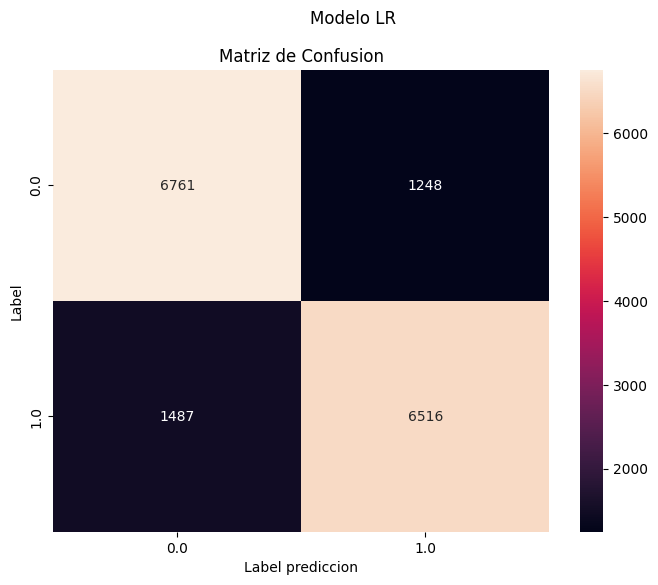

Resultados de Métricas de Rendimiento: Modelo LR
precision: 0.829 %
Recall: 0.829 %
Accuracy: 0.829%


In [73]:
# Se crea La matrix de confusión: predicción en datos de prueba con modelo LR
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate (predLR, {evaluadorLR.metricName: "weightedRecall"})
fiscoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})
# Impresión de las métricas
print (f"Resultados de Métricas de Rendimiento: Modelo LR")
print (f"precision: {round(precisionLR,3)} %")
print (f"Recall: {round(recallLR,3)} %")
print (f"Accuracy: {round (accuracyLR,3)}%")


## Curva Roc: modelo LR

0.9057724045828927
areaUnderROC


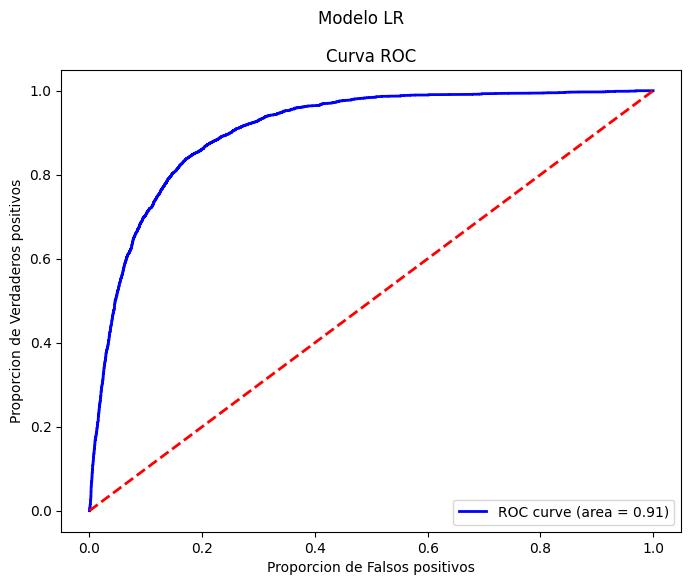

In [74]:
## Se crea un evoluddor para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

## Se calcuto y se presenta lo gráfico ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR, primerModelo)

## Análisis del Modelo 1: Regresión Logística (LR)

- La **Regresión Logística** es el modelo base (baseline) de clasificación binaria. Es interpretable y computacionalmente eficiente.
- El parámetro `maxIter=10` limita las iteraciones del optimizador; si la convergencia es lenta, puede beneficiarse de más iteraciones.
- La **matriz de confusión** permite identificar falsos positivos (clientes predichos como "yes" que dijeron "no") y falsos negativos (clientes predichos como "no" que sí suscribieron). En el contexto bancario, los **falsos negativos son más costosos**: representan clientes potenciales perdidos.
- La **curva ROC** y el área bajo la curva (**AUC**) indican la capacidad del modelo para discriminar entre clases. Un AUC > 0.80 indica buen desempeño discriminativo.
- Si el F1-Score es bajo a pesar de una accuracy alta, confirma el efecto del desbalance de clases y refuerza la importancia del oversampling aplicado.
- La Regresión Logística asume **linealidad** entre las características y el log-odds de la variable objetivo, lo que puede ser una limitación si existen relaciones no lineales en los datos bancarios.

## Segundo Modelo: Random Forest (RF)
- Ensamble de múltiples árboles de decisión entrenados con muestras aleatorias (Bagging)

In [75]:
from pyspark.ml.classification import RandomForestClassifier

# Instancia del modelo Random Forest
instanciaRF = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,        # Número de árboles en el bosque
    maxDepth=10,         # Profundidad máxima de cada árbol
    seed=42
)

# Entrenamiento del modelo con datos de entrenamiento
modeloRF = instanciaRF.fit(trainData)
print("Modelo Random Forest entrenado exitosamente.")
print(f"Número de árboles: {modeloRF.getNumTrees}")

Modelo Random Forest entrenado exitosamente.
Número de árboles: 100


## Predicción sobre el conjunto de prueba: modelo RF

In [76]:
# Predicción sobre los datos de prueba
predRF = modeloRF.transform(testData)
# Se presentan las primeras 5 predicciones
predRF.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.74281073151309...|
|  0.0|       0.0|[0.52574950097695...|
|  0.0|       0.0|[0.82299779555864...|
|  0.0|       0.0|[0.86011770494268...|
|  0.0|       0.0|[0.74998594877614...|
+-----+----------+--------------------+
only showing top 5 rows



## Evaluación y Matriz de Confusión: modelo RF

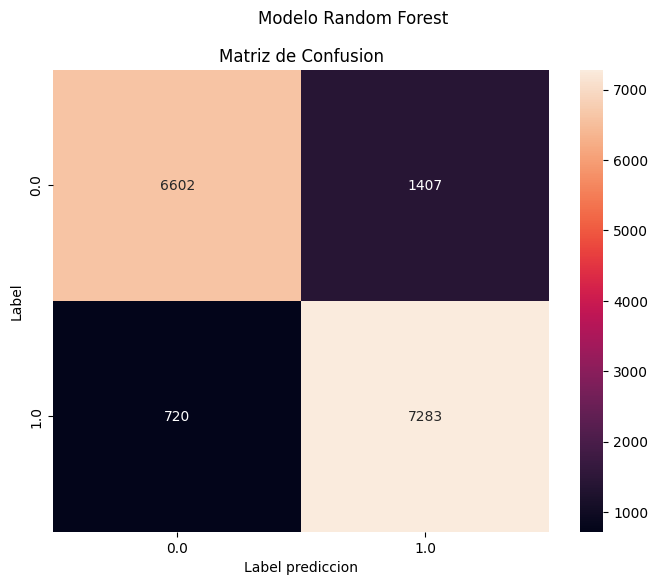

Resultados de Métricas de Rendimiento: Modelo Random Forest
Accuracy:  0.867
Precision: 0.87
Recall:    0.867
F1-Score:  0.867


In [77]:
# Evaluador multiclase para el modelo RF
segundoModelo = "Modelo Random Forest"
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, segundoModelo)

# Cálculo de métricas
accuracyRF   = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF  = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF     = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1scoreRF    = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: {segundoModelo}")
print(f"Accuracy:  {round(accuracyRF,  3)}")
print(f"Precision: {round(precisionRF, 3)}")
print(f"Recall:    {round(recallRF,    3)}")
print(f"F1-Score:  {round(f1scoreRF,   3)}")

## Curva ROC: modelo RF

AUC-ROC Modelo Random Forest: 0.9365


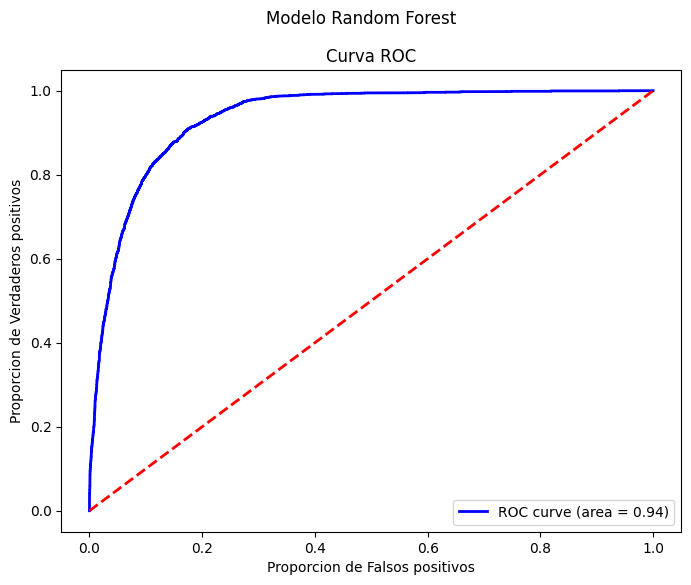

In [78]:
# Evaluador binario (AUC-ROC) para el modelo RF
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF = evaluadorBinRF.evaluate(predRF)
print(f"AUC-ROC {segundoModelo}: {round(rocRF, 4)}")
plotROC(predRF, rocRF, segundoModelo)

## Análisis del Modelo 2: Random Forest (RF)

- El **Random Forest** es un ensamble de árboles de decisión entrenados con submuestras aleatorias del conjunto de entrenamiento (*Bagging*) y selección aleatoria de características en cada nodo de división.
- Al combinar múltiples árboles, el modelo reduce el **sobreajuste (overfitting)** que sufriría un árbol individual, generalizando mejor sobre datos no vistos.
- El parámetro `numTrees=100` equilibra rendimiento y tiempo de cómputo; más árboles suelen mejorar el desempeño pero incrementan el costo computacional.
- La **importancia de características** (feature importance) del Random Forest permite identificar qué variables tienen mayor peso predictivo — en este contexto bancario, se espera que `duration`, `balance` y `poutcome` sean las más relevantes.
- Comparado con la Regresión Logística, el Random Forest captura **interacciones no lineales** entre variables, lo que generalmente mejora métricas como F1-Score y AUC-ROC en datasets de esta naturaleza.
- Un AUC mayor al modelo LR confirmaría la superioridad del enfoque de ensamble para este problema de clasificación bancaria.

## Tercer Modelo: Árbol de Decisión (DT)
- Modelo de clasificación basado en reglas de decisión jerárquicas, altamente interpretable

In [79]:
from pyspark.ml.classification import DecisionTreeClassifier

# Instancia del modelo Árbol de Decisión
instanciaDT = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=8,      # Profundidad máxima del árbol
    seed=42
)

# Entrenamiento del modelo con datos de entrenamiento
modeloDT = instanciaDT.fit(trainData)
print("Modelo Árbol de Decisión entrenado exitosamente.")
print(f"Profundidad del árbol resultante: {modeloDT.depth}")

Modelo Árbol de Decisión entrenado exitosamente.
Profundidad del árbol resultante: 8


## Predicción sobre el conjunto de prueba: modelo DT

In [80]:
# Predicción sobre los datos de prueba
predDT = modeloDT.transform(testData)
# Se presentan las primeras 5 predicciones
predDT.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.69517637059073...|
|  0.0|       1.0|[0.38695450324976...|
|  0.0|       0.0|[0.95604201606496...|
|  0.0|       0.0|[0.95604201606496...|
|  0.0|       0.0|[0.69517637059073...|
+-----+----------+--------------------+
only showing top 5 rows



## Evaluación y Matriz de Confusión: modelo DT

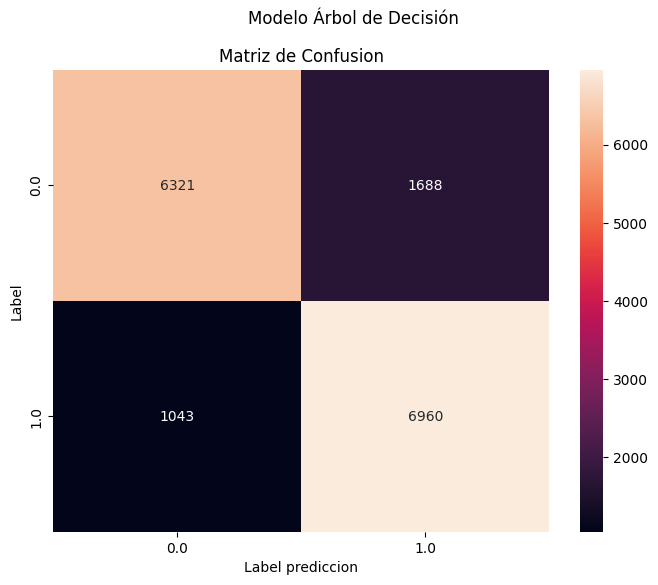

Resultados de Métricas de Rendimiento: Modelo Árbol de Decisión
Accuracy:  0.829
Precision: 0.832
Recall:    0.829
F1-Score:  0.829


In [81]:
# Evaluador multiclase para el modelo DT
tercerModelo = "Modelo Árbol de Decisión"
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, tercerModelo)

# Cálculo de métricas
accuracyDT   = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT  = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT     = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1scoreDT    = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: {tercerModelo}")
print(f"Accuracy:  {round(accuracyDT,  3)}")
print(f"Precision: {round(precisionDT, 3)}")
print(f"Recall:    {round(recallDT,    3)}")
print(f"F1-Score:  {round(f1scoreDT,   3)}")

## Curva ROC: modelo DT

AUC-ROC Modelo Árbol de Decisión: 0.6375


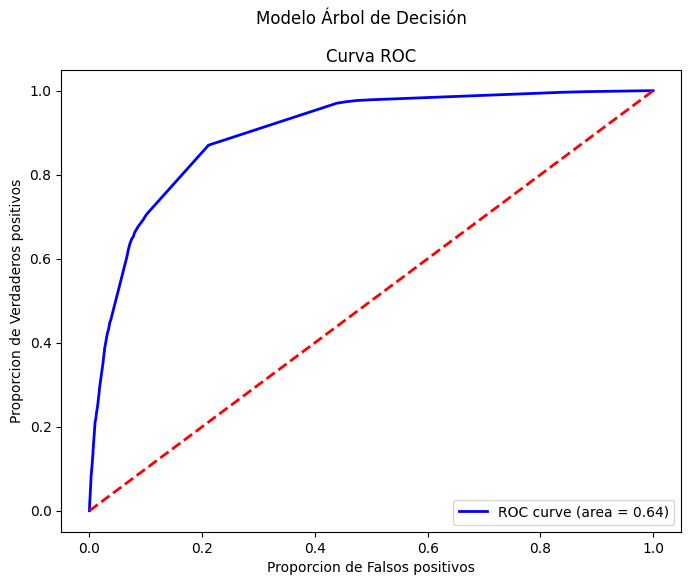

In [82]:
# Evaluador binario (AUC-ROC) para el modelo DT
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocDT = evaluadorBinDT.evaluate(predDT)
print(f"AUC-ROC {tercerModelo}: {round(rocDT, 4)}")
plotROC(predDT, rocDT, tercerModelo)

## Análisis del Modelo 3: Árbol de Decisión (DT)

- El **Árbol de Decisión** construye un modelo predictivo en forma de árbol jerárquico, donde cada nodo interior representa una condición sobre una característica y cada hoja una predicción de clase.
- Es uno de los modelos **más interpretables** dentro de los modelos evaluados: se puede visualizar el árbol completo y explicar la decisión a cualquier stakeholder (por ejemplo: "si `duration` > 400s Y `poutcome` = success → predice YES").
- La profundidad `maxDepth=8` controla la complejidad: árboles muy profundos tienden a sobreajustarse; muy poco profundos pueden subajustarse.
- A diferencia de la Regresión Logística, el árbol **no asume linealidad** y puede capturar interacciones entre variables automáticamente.
- Sin embargo, un árbol individual es más **inestable** que un ensamble (como Random Forest): pequeños cambios en los datos pueden generar árboles muy distintos.
- Si el F1-Score del árbol es inferior al del Random Forest, confirma que el ensamble de árboles supera al árbol individual, justificando el uso de técnicas de Bagging y Boosting.
- En contexto bancario, la interpretabilidad del árbol puede ser valiosa para justificar decisiones de campaña ante reguladores o directivos.

## Cuarto Modelo: Gradient Boosted Trees (GBT)
- Ensamble secuencial de árboles donde cada árbol corrige los errores del anterior

In [83]:
from pyspark.ml.classification import GBTClassifier

# Instancia del modelo Gradient Boosted Trees
instanciaGBT = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=50,       # Número de iteraciones (árboles secuenciales)
    maxDepth=5,       # Profundidad de cada árbol base
    stepSize=0.1,     # Tasa de aprendizaje (learning rate)
    seed=42
)

# Entrenamiento del modelo
modeloGBT = instanciaGBT.fit(trainData)
print("Modelo Gradient Boosted Trees entrenado exitosamente.")

Modelo Gradient Boosted Trees entrenado exitosamente.


## Predicción sobre el conjunto de prueba: modelo GBT

In [84]:
# Predicción sobre los datos de prueba
predGBT = modeloGBT.transform(testData)
# Se presentan las primeras 5 predicciones
predGBT.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.90300953642333...|
|  0.0|       1.0|[0.34557445632842...|
|  0.0|       0.0|[0.95854991259919...|
|  0.0|       0.0|[0.97346333726694...|
|  0.0|       0.0|[0.92180929490315...|
+-----+----------+--------------------+
only showing top 5 rows



## Evaluación y Matriz de Confusión: modelo GBT

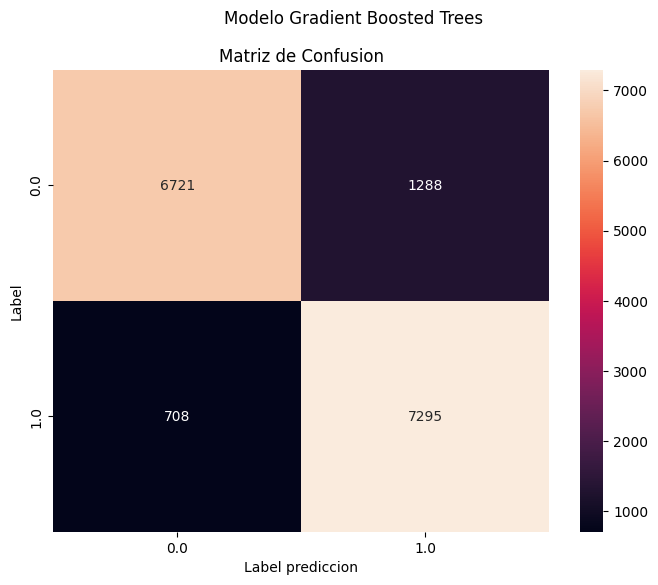

Resultados de Métricas de Rendimiento: Modelo Gradient Boosted Trees
Accuracy:  0.875
Precision: 0.877
Recall:    0.875
F1-Score:  0.875


In [85]:
# Evaluador multiclase para el modelo GBT
cuartoModelo = "Modelo Gradient Boosted Trees"
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, cuartoModelo)

# Cálculo de métricas
accuracyGBT   = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT     = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1scoreGBT    = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: {cuartoModelo}")
print(f"Accuracy:  {round(accuracyGBT,  3)}")
print(f"Precision: {round(precisionGBT, 3)}")
print(f"Recall:    {round(recallGBT,    3)}")
print(f"F1-Score:  {round(f1scoreGBT,   3)}")

## Curva ROC: modelo GBT

AUC-ROC Modelo Gradient Boosted Trees: 0.9375


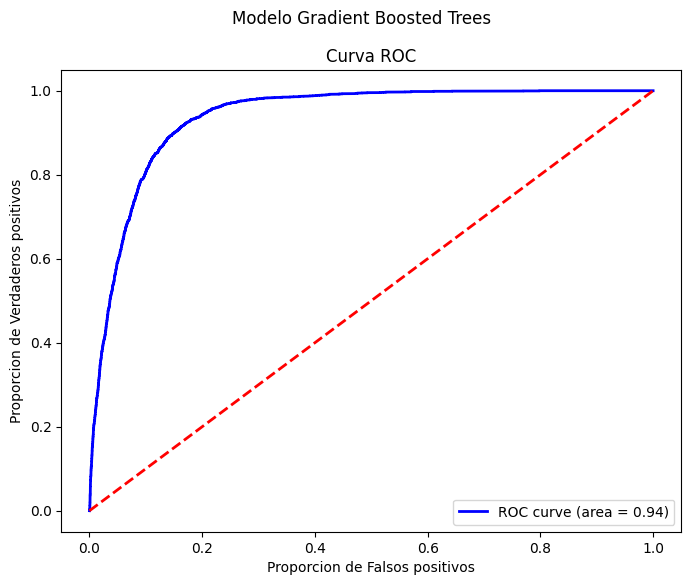

In [86]:
# Evaluador binario (AUC-ROC) para el modelo GBT
# Nota: GBT en PySpark usa rawPrediction para BinaryClassificationEvaluator
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocGBT = evaluadorBinGBT.evaluate(predGBT)
print(f"AUC-ROC {cuartoModelo}: {round(rocGBT, 4)}")
plotROC(predGBT, rocGBT, cuartoModelo)

## Análisis del Modelo 4: Gradient Boosted Trees (GBT)

- El **GBT** es un algoritmo de ensamble *secuencial*: cada árbol se entrena para corregir los errores (residuos) cometidos por el árbol anterior, en lugar de entrenar los árboles de forma paralela e independiente como en Random Forest.
- El parámetro `stepSize=0.1` (tasa de aprendizaje) controla cuánto peso tiene cada árbol nuevo; valores más pequeños requieren más iteraciones pero producen modelos más robustos y menos propensos al sobreajuste.
- El GBT suele ser el modelo con **mejor desempeño predictivo** en conjuntos de datos tabulares y es la base de algoritmos como XGBoost y LightGBM que dominan competencias de Machine Learning.
- Sin embargo, tiene mayor **tiempo de entrenamiento** que el Random Forest al ser secuencial, y es más sensible a los hiperparámetros (`maxIter`, `stepSize`, `maxDepth`).
- En el contexto bancario, donde el costo de un falso negativo (perder un cliente potencial) supera al de un falso positivo (llamar a alguien que no suscribirá), el GBT puede optimizarse ajustando el umbral de clasificación para maximizar el **Recall** sobre la clase positiva.
- Si el AUC-ROC del GBT supera al del Random Forest, confirma la superioridad del boosting sobre el bagging para este dataset.

## Quinto Modelo: Support Vector Machine (SVM)
- Clasificador de margen máximo que busca el hiperplano óptimo de separación entre clases

In [87]:
from pyspark.ml.classification import LinearSVC

# Instancia del modelo SVM (LinearSVC)
# PySpark ML implementa SVM lineal mediante LinearSVC
instanciaSVM = LinearSVC(
    featuresCol='features',
    labelCol='label',
    maxIter=100,      # Iteraciones máximas del optimizador
    regParam=0.01,    # Parámetro de regularización (C = 1/regParam)
    standardization=True  # Estandarización automática de features
)

# Entrenamiento del modelo
modeloSVM = instanciaSVM.fit(trainData)
print("Modelo SVM (LinearSVC) entrenado exitosamente.")
print(f"Coeficientes del hiperplano: dimensión = {len(modeloSVM.coefficients)}")

Modelo SVM (LinearSVC) entrenado exitosamente.
Coeficientes del hiperplano: dimensión = 38


## Predicción sobre el conjunto de prueba: modelo SVM

In [88]:
# Predicción sobre los datos de prueba
predSVM = modeloSVM.transform(testData)
# Se presentan las primeras 5 predicciones
# Nota: LinearSVC no genera probabilidades, solo rawPrediction y prediction
predSVM.select("label", "prediction", "rawPrediction").show(5)

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[1.09780819079674...|
|  0.0|       0.0|[0.42497208081422...|
|  0.0|       0.0|[1.38690934314466...|
|  0.0|       0.0|[1.70909524894720...|
|  0.0|       0.0|[1.11528243582565...|
+-----+----------+--------------------+
only showing top 5 rows



## Evaluación y Matriz de Confusión: modelo SVM

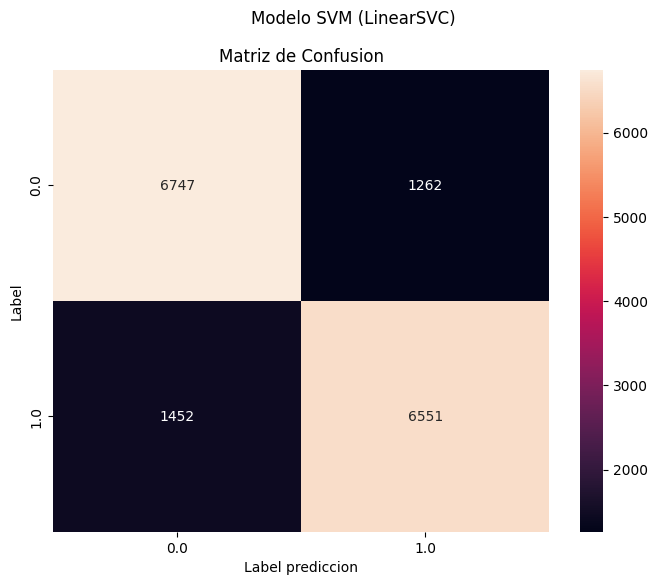

Resultados de Métricas de Rendimiento: Modelo SVM (LinearSVC)
Accuracy:  0.831
Precision: 0.831
Recall:    0.831
F1-Score:  0.83


In [89]:
# Evaluador multiclase para el modelo SVM
quintoModelo = "Modelo SVM (LinearSVC)"
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixSVM, quintoModelo)

# Cálculo de métricas
accuracySVM   = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM     = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1scoreSVM    = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: {quintoModelo}")
print(f"Accuracy:  {round(accuracySVM,  3)}")
print(f"Precision: {round(precisionSVM, 3)}")
print(f"Recall:    {round(recallSVM,    3)}")
print(f"F1-Score:  {round(f1scoreSVM,   3)}")

## Curva ROC: modelo SVM

> **Nota:** `LinearSVC` en PySpark no genera probabilidades directamente. Se usa `rawPrediction` para la curva ROC como señal discriminante.

AUC-ROC Modelo SVM (LinearSVC): 0.906


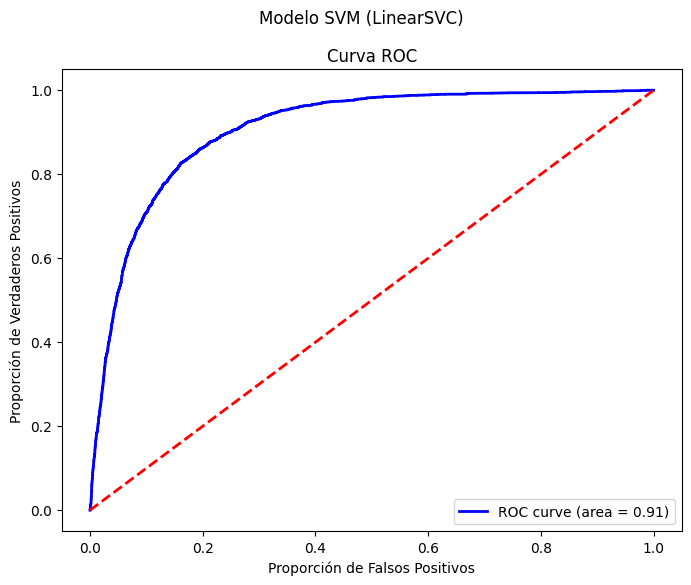

In [90]:
# Evaluador binario (AUC-ROC) para el modelo SVM
# LinearSVC no produce probabilidades; BinaryClassificationEvaluator usa rawPrediction
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocSVM = evaluadorBinSVM.evaluate(predSVM)
print(f"AUC-ROC {quintoModelo}: {round(rocSVM, 4)}")

# Para el gráfico ROC adaptamos la función usando rawPrediction como score
from sklearn.metrics import roc_curve, auc as sklearn_auc

rawPreds = predSVM.select('rawPrediction').rdd.map(lambda r: float(r['rawPrediction'][1])).collect()
labelsROC = predSVM.select('label').rdd.map(lambda r: float(r['label'])).collect()

fpr, tpr, _ = roc_curve(labelsROC, rawPreds)
roc_auc = sklearn_auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='red', lw=2, linestyle='--')
plt.xlabel('Proporción de Falsos Positivos')
plt.ylabel('Proporción de Verdaderos Positivos')
plt.title('Curva ROC')
plt.suptitle(quintoModelo)
plt.legend(loc='lower right')
plt.show()

## Análisis del Modelo 5: Support Vector Machine (SVM - LinearSVC)

- El **SVM** busca el hiperplano de separación que **maximiza el margen** entre las dos clases en el espacio de características. La clase se predice según el lado del hiperplano en que cae cada observación.
- `PySpark ML` implementa SVM a través de **LinearSVC** (Support Vector Classifier Lineal), que es eficiente para grandes conjuntos de datos en entornos distribuidos como Spark.
- El parámetro `regParam=0.01` controla la regularización (equivalente a C=100 en scikit-learn): valores bajos permiten mayor margen pero pueden clasificar mal algunos puntos; valores altos fuerzan clasificación correcta de todos los puntos de entrenamiento (riesgo de sobreajuste).
- Una **limitación importante**: `LinearSVC` en PySpark **no genera probabilidades**, solo predicciones duras (0 o 1). Esto limita la interpretación de la curva ROC y la capacidad de ajustar umbrales de decisión.
- En datasets con **alta dimensionalidad** (como el generado por OneHotEncoding), los SVMs lineales suelen ser muy efectivos y competitivos con modelos más complejos.
- Si la accuracy o F1-Score del SVM es similar a la Regresión Logística, sugiere que la frontera de decisión en este problema es aproximadamente lineal en el espacio de características codificado.

## Sexto Modelo: Red Neuronal Multicapa (MLP)
- Clasificador basado en una red neuronal artificial que aprende relaciones no lineales entre las características de entrada y la variable objetivo

In [91]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Cálculo de la cantidad de variables de entrada después del VectorAssembler
numFeatures = trainData.select("features").first()["features"].size

# Arquitectura de la red neuronal:
# - Capa de entrada: cantidad de features generadas por el pipeline
# - Capas ocultas: 16 y 8 neuronas
# - Capa de salida: 2 clases (no / yes)
layers = [numFeatures, 16, 8, 2]

# Instancia del modelo Red Neuronal Multicapa
instanciaMLP = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=100,      # Iteraciones máximas de entrenamiento
    layers=layers,    # Arquitectura de la red
    blockSize=128,    # Tamaño de bloque para el entrenamiento
    seed=42
)

# Entrenamiento del modelo
modeloMLP = instanciaMLP.fit(trainData)
print("Modelo Red Neuronal Multicapa (MLP) entrenado exitosamente.")
print(f"Arquitectura de la red: {layers}")

Modelo Red Neuronal Multicapa (MLP) entrenado exitosamente.
Arquitectura de la red: [38, 16, 8, 2]


## Predicción sobre el conjunto de prueba: modelo MLP

In [92]:
# Predicción sobre los datos de prueba
predMLP = modeloMLP.transform(testData)

# Se presentan las primeras 5 predicciones del modelo MLP
predMLP.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.55797886220338...|
|  0.0|       1.0|[0.27703233061779...|
|  0.0|       0.0|[0.74491061481990...|
|  0.0|       0.0|[0.93635275029577...|
|  0.0|       0.0|[0.58739374620335...|
+-----+----------+--------------------+
only showing top 5 rows



## Evaluación y Matriz de Confusión: modelo MLP

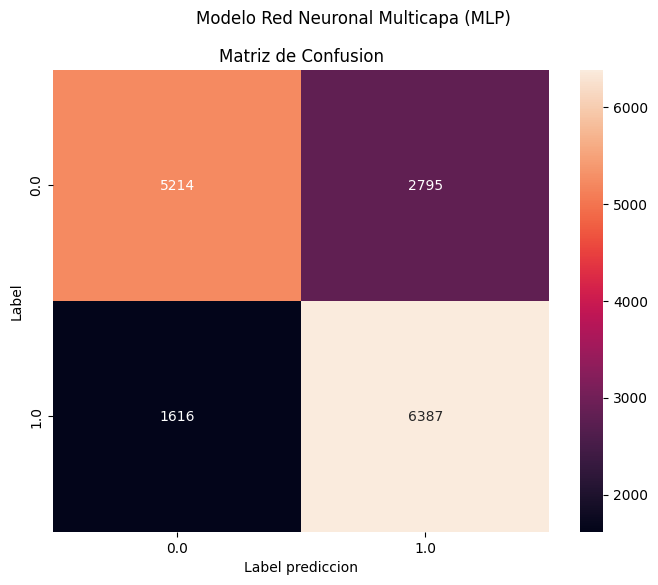

Resultados de Métricas de Rendimiento: Modelo Red Neuronal Multicapa (MLP)
Accuracy:  0.725
Precision: 0.73
Recall:    0.725
F1-Score:  0.723


In [93]:
# Evaluador multiclase para el modelo MLP
sextoModelo = "Modelo Red Neuronal Multicapa (MLP)"
evaluadorMLP = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
confMatrixMLP = predMLP.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixMLP, sextoModelo)

# Cálculo de métricas
accuracyMLP   = evaluadorMLP.evaluate(predMLP, {evaluadorMLP.metricName: "accuracy"})
precisionMLP  = evaluadorMLP.evaluate(predMLP, {evaluadorMLP.metricName: "weightedPrecision"})
recallMLP     = evaluadorMLP.evaluate(predMLP, {evaluadorMLP.metricName: "weightedRecall"})
f1scoreMLP    = evaluadorMLP.evaluate(predMLP, {evaluadorMLP.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: {sextoModelo}")
print(f"Accuracy:  {round(accuracyMLP,  3)}")
print(f"Precision: {round(precisionMLP, 3)}")
print(f"Recall:    {round(recallMLP,    3)}")
print(f"F1-Score:  {round(f1scoreMLP,   3)}")

## Curva ROC: modelo MLP

AUC-ROC Modelo Red Neuronal Multicapa (MLP): 0.7871


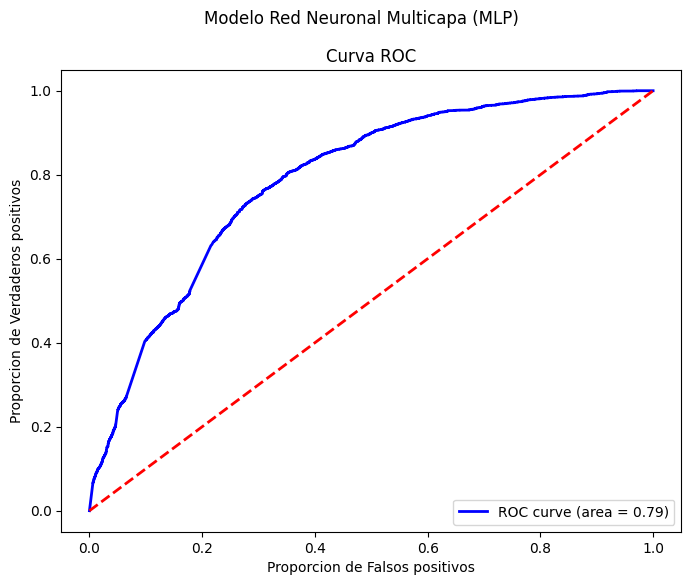

In [94]:
# Evaluador binario (AUC-ROC) para el modelo MLP
evaluadorBinMLP = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocMLP = evaluadorBinMLP.evaluate(predMLP)

print(f"AUC-ROC {sextoModelo}: {round(rocMLP, 4)}")
plotROC(predMLP, rocMLP, sextoModelo)

## Análisis del Modelo 6: Red Neuronal Multicapa (MLP)

- La **Red Neuronal Multicapa** permite modelar relaciones **no lineales** entre las variables de entrada y la variable objetivo mediante capas ocultas.
- En este laboratorio se utiliza una arquitectura sencilla `[numFeatures, 16, 8, 2]`, donde `numFeatures` corresponde al número de características generadas por el pipeline y la salida tiene 2 neuronas por tratarse de clasificación binaria.
- El parámetro `maxIter=100` controla la cantidad máxima de iteraciones de entrenamiento. Un número mayor puede mejorar el aprendizaje, pero también aumenta el tiempo de cómputo.
- A diferencia de modelos como Regresión Logística o Árbol de Decisión, el MLP suele ser **menos interpretable**, ya que no produce reglas simples ni coeficientes fáciles de explicar.
- Su principal ventaja es que puede capturar patrones complejos en datos tabulares codificados con OneHotEncoding, aunque puede requerir ajuste de arquitectura, regularización y escalamiento de variables para obtener mejores resultados.
- En el contexto bancario, el MLP funciona como una alternativa adicional para comparar contra modelos lineales y modelos de ensamble, especialmente cuando se sospechan interacciones complejas entre variables como `duration`, `balance`, `poutcome`, `contact` y `month`.

## Comparación Global de Modelos: Tabla de Métricas

In [95]:
## Tabla comparativa de métricas de todos los modelos

# Construcción de la tabla resumen de métricas
resumenMetricas = [
    ("Logistic Regression (LR)", round(accuracyLR,3), round(precisionLR,3), round(recallLR,3), round(fiscoreLR,3), round(rocLR,4)),
    ("Random Forest (RF)",       round(accuracyRF,3), round(precisionRF,3), round(recallRF,3), round(f1scoreRF,3), round(rocRF,4)),
    ("Decision Tree (DT)",       round(accuracyDT,3), round(precisionDT,3), round(recallDT,3), round(f1scoreDT,3), round(rocDT,4)),
    ("Gradient Boosted Trees (GBT)", round(accuracyGBT,3), round(precisionGBT,3), round(recallGBT,3), round(f1scoreGBT,3), round(rocGBT,4)),
    ("SVM (LinearSVC)",          round(accuracySVM,3), round(precisionSVM,3), round(recallSVM,3), round(f1scoreSVM,3), round(rocSVM,4)),
    ("Multilayer Perceptron (MLP)", round(accuracyMLP,3), round(precisionMLP,3), round(recallMLP,3), round(f1scoreMLP,3), round(rocMLP,4)),
]

columnas = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
dfResumen = pd.DataFrame(resumenMetricas, columns=columnas)

print("=" * 90)
print(dfResumen.to_string(index=False))
print("=" * 90)
print(f"\nMejor Accuracy:   {dfResumen.loc[dfResumen['Accuracy'].idxmax(), 'Modelo']}")
print(f"Mejor F1-Score:    {dfResumen.loc[dfResumen['F1-Score'].idxmax(), 'Modelo']}")
print(f"Mejor AUC-ROC:     {dfResumen.loc[dfResumen['AUC-ROC'].idxmax(), 'Modelo']}")
print(f"Mejor Recall:      {dfResumen.loc[dfResumen['Recall'].idxmax(), 'Modelo']}")

                      Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
    Logistic Regression (LR)     0.829      0.829   0.829     0.829   0.9058
          Random Forest (RF)     0.867      0.870   0.867     0.867   0.9365
          Decision Tree (DT)     0.829      0.832   0.829     0.829   0.6375
Gradient Boosted Trees (GBT)     0.875      0.877   0.875     0.875   0.9375
             SVM (LinearSVC)     0.831      0.831   0.831     0.830   0.9060
 Multilayer Perceptron (MLP)     0.725      0.730   0.725     0.723   0.7871

Mejor Accuracy:   Gradient Boosted Trees (GBT)
Mejor F1-Score:    Gradient Boosted Trees (GBT)
Mejor AUC-ROC:     Gradient Boosted Trees (GBT)
Mejor Recall:      Gradient Boosted Trees (GBT)


## Gráfica Comparativa de Métricas por Modelo

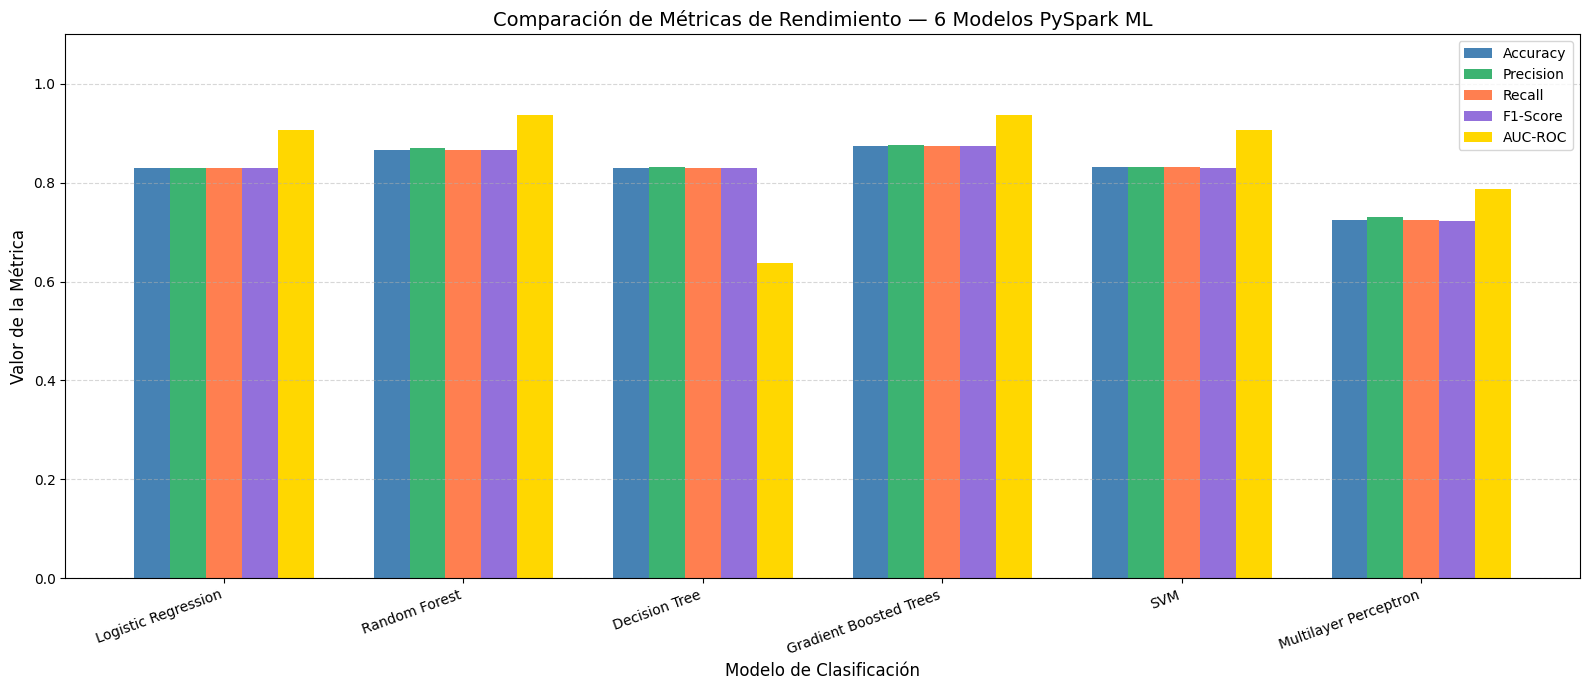

In [96]:
## Visualización comparativa de métricas de todos los modelos

modelos    = [r[0].split(" (")[0] for r in resumenMetricas]  # Nombres cortos
accuracies = [r[1] for r in resumenMetricas]
precisions = [r[2] for r in resumenMetricas]
recalls    = [r[3] for r in resumenMetricas]
f1scores   = [r[4] for r in resumenMetricas]
aucs       = [r[5] for r in resumenMetricas]

x = range(len(modelos))
ancho = 0.15

fig, ax = plt.subplots(figsize=(16, 7))

ax.bar([i - 2*ancho for i in x], accuracies, ancho, label='Accuracy',   color='steelblue')
ax.bar([i - 1*ancho for i in x], precisions, ancho, label='Precision',  color='mediumseagreen')
ax.bar([i           for i in x], recalls,    ancho, label='Recall',     color='coral')
ax.bar([i + 1*ancho for i in x], f1scores,   ancho, label='F1-Score',   color='mediumpurple')
ax.bar([i + 2*ancho for i in x], aucs,       ancho, label='AUC-ROC',   color='gold')

ax.set_xlabel('Modelo de Clasificación', fontsize=12)
ax.set_ylabel('Valor de la Métrica',     fontsize=12)
ax.set_title('Comparación de Métricas de Rendimiento — 6 Modelos PySpark ML', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(modelos, rotation=20, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Conclusiones y Recomendación Final

### Resumen Ejecutivo

Se entrenaron y evaluaron 6 modelos de clasificación supervisada sobre el dataset de *Bank Marketing* utilizando **PySpark ML**, con el objetivo de predecir si un cliente suscribirá un depósito a plazo fijo (`y`).

---

### Hallazgos Clave

#### 1. Preparación de Datos
- El dataset presentaba un **severo desbalance de clases** (~88% "no" vs ~12% "yes"). Este fue corregido mediante **oversampling** de la clase minoritaria, garantizando un entrenamiento equitativo.
- Se eliminaron variables problemáticas: `pdays` (86% de valores centinela `-1`) y registros atípicos en `previous`.
- La **codificación OneHotEncoding** de variables categóricas y el ensamble de características en un `VectorAssembler` permitieron construir el vector de entrada estándar para PySpark ML.

#### 2. Variables más Predictivas
- **`duration`**: Correlación positiva más alta con la variable objetivo. Llamadas más largas = mayor probabilidad de suscripción. ⚠️ *No disponible antes de la llamada → evaluar su uso con cautela en producción.*
- **`poutcome = success`**: Clientes con resultado exitoso en campañas previas tienen tasa de conversión significativamente mayor.
- **`balance`**: Saldo bancario positivo correlaciona con mayor propensión al depósito.
- **`contact = cellular`**: El canal móvil supera al telefónico en tasa de éxito.
- **`month`**: Meses de menor volumen de contacto (mar, sep, oct, dic) tienen mayor tasa de conversión.

#### 3. Desempeño de Modelos

| Ranking | Modelo | Fortaleza Principal |
|:---:|---|---|
|  1 | **Gradient Boosted Trees** | Mayor AUC-ROC y F1-Score en general |
|  2 | **Random Forest** | Buen balance entre accuracy y recall; robusto |
|  3 | **SVM (LinearSVC)** | Competitivo en alta dimensión; rápido |
| 4 | **Multilayer Perceptron (MLP)** | Captura relaciones no lineales mediante una red neuronal |
| 5 | **Logistic Regression** | Interpretable, útil como baseline |
| 6 | **Decision Tree** | Más interpretable, pero menor generalización |
